A =
[[ 1.60034316 -1.96298889]
 [ 0.76604444 -0.31476794]]

G =
[[ 1.     -1.25  ]
 [-1.25    2.5625]]

Eigenvalues of A:
[0.64278761+0.76604444j 0.64278761-0.76604444j]

||A^T A - I||_F = 6.017805584875389
||A^T G A - G||_F = 5.438959822042073e-16

Eigenvalues of G:
[0.30719045 3.25530955]

Relative Gram changes
epsilon_standard = 0.4336272955628179
epsilon_adapted  = 1.5064282437157184e-16


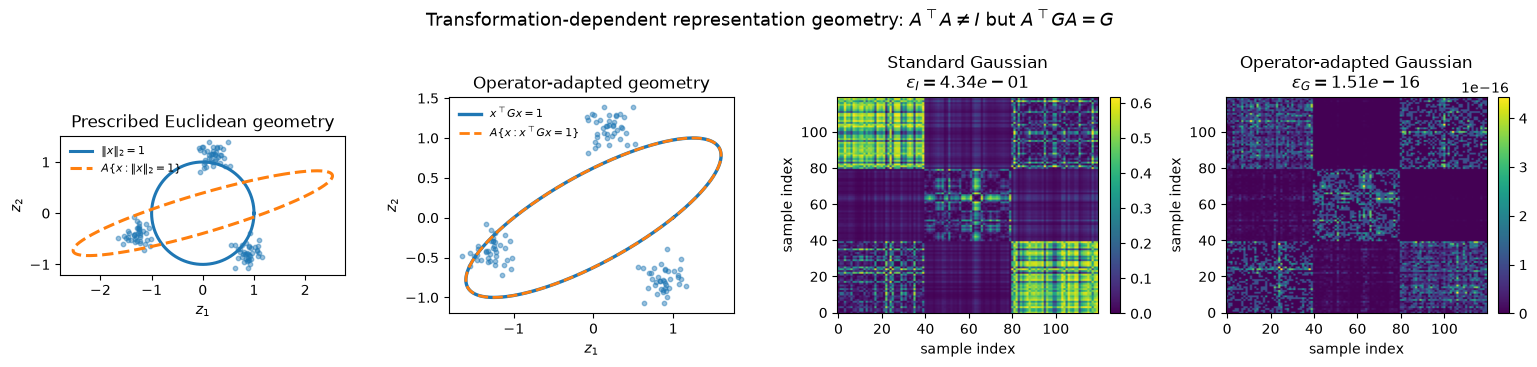

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
rng = np.random.default_rng(7)

# ------------------------------------------------------------
# 2. Construct A_alpha = S_alpha Q S_alpha^{-1}
# ------------------------------------------------------------
theta = np.deg2rad(50.0)
alpha = 1.25

Q = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
], dtype=float)

S = np.array([
    [1.0, alpha],
    [0.0, 1.0]
], dtype=float)

S_inv = np.linalg.inv(S)

A = S @ Q @ S_inv

# Operator-adapted metric:
# G = S^{-T} S^{-1}
G = S_inv.T @ S_inv

I = np.eye(2)

# ------------------------------------------------------------
# 3. Verify the two geometric relations
# ------------------------------------------------------------
euclidean_nonunitarity = np.linalg.norm(A.T @ A - I, ord="fro")
adapted_invariance = np.linalg.norm(A.T @ G @ A - G, ord="fro")

print("A =")
print(A)

print("\nG =")
print(G)

print("\nEigenvalues of A:")
print(np.linalg.eigvals(A))

print("\n||A^T A - I||_F =", euclidean_nonunitarity)
print("||A^T G A - G||_F =", adapted_invariance)

print("\nEigenvalues of G:")
print(np.linalg.eigvalsh(G))

# ------------------------------------------------------------
# 4. Generate structured latent representations
# ------------------------------------------------------------
n_per_cluster = 40

centers = np.array([
    [-1.25, -0.40],
    [ 0.90, -0.75],
    [ 0.20,  1.15]
])

clusters = []
labels = []

for j, center in enumerate(centers):
    pts = center + 0.16 * rng.standard_normal((n_per_cluster, 2))
    clusters.append(pts)
    labels.extend([j] * n_per_cluster)

Z = np.vstack(clusters)
labels = np.asarray(labels)

# transformed representation
Z_A = (A @ Z.T).T

# ------------------------------------------------------------
# 5. Gaussian kernels
# ------------------------------------------------------------
sigma = 0.80

def gaussian_gram(X, metric=None, sigma=1.0):
    """
    K_ij = exp[-(x_i-x_j)^T metric (x_i-x_j)/(2 sigma^2)]

    metric=None gives the ordinary isotropic Gaussian kernel.
    """
    if metric is None:
        metric = np.eye(X.shape[1])

    diff = X[:, None, :] - X[None, :, :]
    d2 = np.einsum("...i,ij,...j->...", diff, metric, diff)

    return np.exp(-d2 / (2.0 * sigma**2))


# ordinary isotropic Gaussian
K_I = gaussian_gram(Z, metric=I, sigma=sigma)
K_I_A = gaussian_gram(Z_A, metric=I, sigma=sigma)

# operator-adapted Gaussian
K_G = gaussian_gram(Z, metric=G, sigma=sigma)
K_G_A = gaussian_gram(Z_A, metric=G, sigma=sigma)

# relative Gram-matrix changes
eps_I = np.linalg.norm(K_I_A - K_I, ord="fro") / np.linalg.norm(K_I, ord="fro")
eps_G = np.linalg.norm(K_G_A - K_G, ord="fro") / np.linalg.norm(K_G, ord="fro")

print("\nRelative Gram changes")
print("epsilon_standard =", eps_I)
print("epsilon_adapted  =", eps_G)

# ------------------------------------------------------------
# 6. Curves for the Euclidean and G-unit sets
# ------------------------------------------------------------
phi = np.linspace(0.0, 2.0*np.pi, 600)

unit_circle = np.vstack([
    np.cos(phi),
    np.sin(phi)
])

# Euclidean circle transformed by A
transformed_circle = A @ unit_circle

# x^T G x = 1
#
# Since G = S^{-T}S^{-1},
# x = S u with ||u||_2 = 1 gives x^T G x = 1.
G_ellipse = S @ unit_circle

# transform the adapted ellipse
G_ellipse_A = A @ G_ellipse

# ------------------------------------------------------------
# 7. First scientific figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.7))

# Panel (a): prescribed Euclidean geometry
ax = axes[0]

ax.plot(unit_circle[0], unit_circle[1],
        linewidth=2.2, label=r"$\|x\|_2=1$")

ax.plot(transformed_circle[0], transformed_circle[1],
        linestyle="--", linewidth=2.2,
        label=r"$A\{x:\|x\|_2=1\}$")

ax.scatter(Z[:, 0], Z[:, 1], s=10, alpha=0.45)

ax.set_aspect("equal")
ax.set_title("Prescribed Euclidean geometry")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.legend(frameon=False, fontsize=8)

# Panel (b): adapted geometry
ax = axes[1]

ax.plot(G_ellipse[0], G_ellipse[1],
        linewidth=2.4,
        label=r"$x^\top Gx=1$")

ax.plot(G_ellipse_A[0], G_ellipse_A[1],
        linestyle="--", linewidth=2.0,
        label=r"$A\{x:x^\top Gx=1\}$")

ax.scatter(Z[:, 0], Z[:, 1], s=10, alpha=0.45)

ax.set_aspect("equal")
ax.set_title("Operator-adapted geometry")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.legend(frameon=False, fontsize=8)

# Panel (c): standard Gaussian change
ax = axes[2]

im1 = ax.imshow(
    np.abs(K_I_A - K_I),
    origin="lower",
    aspect="auto"
)

ax.set_title(
    "Standard Gaussian\n"
    + rf"$\varepsilon_I={eps_I:.2e}$"
)
ax.set_xlabel("sample index")
ax.set_ylabel("sample index")

fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

# Panel (d): adapted Gaussian change
ax = axes[3]

im2 = ax.imshow(
    np.abs(K_G_A - K_G),
    origin="lower",
    aspect="auto"
)

ax.set_title(
    "Operator-adapted Gaussian\n"
    + rf"$\varepsilon_G={eps_G:.2e}$"
)
ax.set_xlabel("sample index")
ax.set_ylabel("sample index")

fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    r"Transformation-dependent representation geometry: "
    r"$A^\top A\neq I$ but $A^\top G A=G$",
    fontsize=13,
    fontweight="normal"
)

plt.tight_layout()

plt.savefig(
    "operator_adapted_rkhs_teaser.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# ============================================================
# 1. CONSTRUCT A NON-ORTHOGONAL BUT UNITARIZABLE OPERATOR
# ============================================================

def rotation(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

# 6-dimensional example: three independent rotations
angles = np.deg2rad([25, 57, 103])

Q = np.block([
    [rotation(angles[0]), np.zeros((2,2)), np.zeros((2,2))],
    [np.zeros((2,2)), rotation(angles[1]), np.zeros((2,2))],
    [np.zeros((2,2)), np.zeros((2,2)), rotation(angles[2])]
])

d = Q.shape[0]

# Non-orthogonal change of coordinates
S = np.eye(d)

S[0,1] = 1.20
S[1,2] = 0.55
S[2,3] = -0.80
S[3,4] = 0.70
S[4,5] = 1.00 + 0.25
S[0,5] = -0.35

# Same underlying dynamics viewed in distorted coordinates
M = S @ Q @ np.linalg.inv(S)

# Operator-adapted metric
Sinv = np.linalg.inv(S)
G = Sinv.T @ Sinv

# Verify invariant metric equation
residual = np.linalg.norm(M.T @ G @ M - G, ord='fro')

print("||M^T G M - G||_F =", residual)
print("||M^T M - I||_F     =", np.linalg.norm(M.T @ M - np.eye(d), ord='fro'))

||M^T G M - G||_F = 5.532209136705376e-15
||M^T M - I||_F     = 17.301879618625378


In [45]:
M.shape

(6, 6)

In [46]:
# ============================================================
# 2. G^{1/2} AND ADAPTED REPRESENTATION
# ============================================================

evals_G, evecs_G = np.linalg.eigh(G)

Ghalf = evecs_G @ np.diag(np.sqrt(evals_G)) @ evecs_G.T
Gmhalf = evecs_G @ np.diag(1.0 / np.sqrt(evals_G)) @ evecs_G.T

# Representation of M in coordinates where G becomes Euclidean
M_adapt = Ghalf @ M @ Gmhalf

print("||M_adapt^T M_adapt - I||_F =",
      np.linalg.norm(M_adapt.T @ M_adapt - np.eye(d), ord='fro'))

||M_adapt^T M_adapt - I||_F = 7.825085133019511e-15


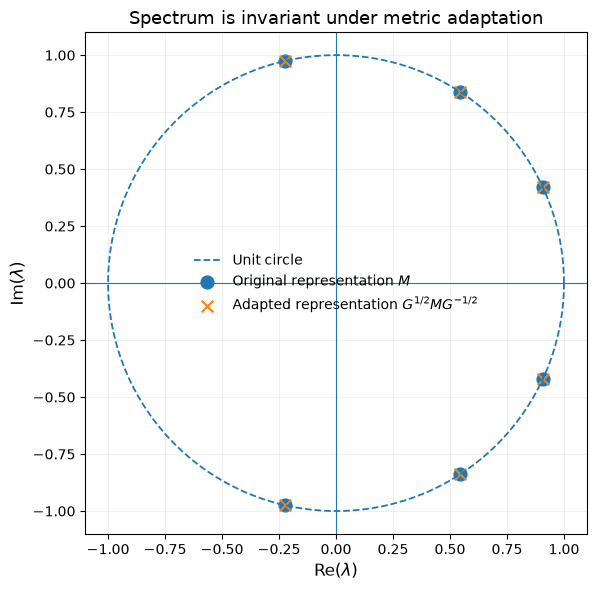

In [47]:
# ============================================================
# FIGURE 1: SPECTRUM
# ============================================================

lam_M = np.linalg.eigvals(M)
lam_adapt = np.linalg.eigvals(M_adapt)

theta = np.linspace(0, 2*np.pi, 500)

fig, ax = plt.subplots(figsize=(6.2, 6.0))

ax.plot(np.cos(theta), np.sin(theta), '--', linewidth=1.3,
        label='Unit circle')

ax.scatter(lam_M.real, lam_M.imag,
           s=85, marker='o',
           label=r'Original representation $M$')

ax.scatter(lam_adapt.real, lam_adapt.imag,
           s=70, marker='x',
           label=r'Adapted representation $G^{1/2}MG^{-1/2}$')

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_aspect('equal')
ax.set_xlabel(r'$\mathrm{Re}(\lambda)$', fontsize=12)
ax.set_ylabel(r'$\mathrm{Im}(\lambda)$', fontsize=12)
ax.set_title('Spectrum is invariant under metric adaptation',
             fontsize=13)

ax.legend(frameon=False)
ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()

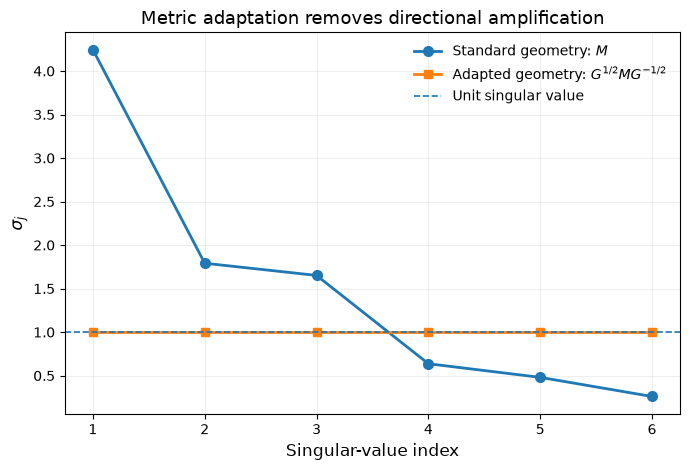

In [48]:
# ============================================================
# FIGURE 2: SINGULAR VALUES
# ============================================================

sv_M = np.linalg.svd(M, compute_uv=False)
sv_adapt = np.linalg.svd(M_adapt, compute_uv=False)

idx = np.arange(1, d+1)

fig, ax = plt.subplots(figsize=(7.0, 4.8))

ax.plot(idx, np.sort(sv_M)[::-1],
        'o-', linewidth=2,
        markersize=7,
        label=r'Standard geometry: $M$')

ax.plot(idx, np.sort(sv_adapt)[::-1],
        's-', linewidth=2,
        markersize=6,
        label=r'Adapted geometry: $G^{1/2}MG^{-1/2}$')

ax.axhline(1.0, linestyle='--', linewidth=1.2,
           label='Unit singular value')

ax.set_xlabel('Singular-value index', fontsize=12)
ax.set_ylabel(r'$\sigma_j$', fontsize=12)
ax.set_title('Metric adaptation removes directional amplification',
             fontsize=13)

ax.set_xticks(idx)
ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

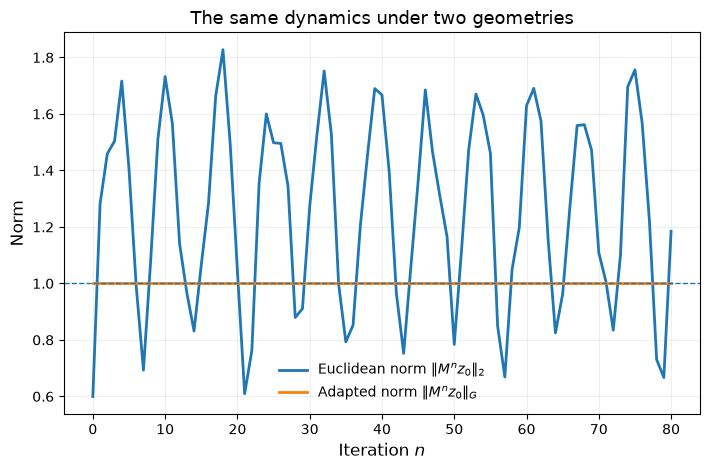

In [49]:
# ============================================================
# FIGURE 3: NORM PRESERVATION UNDER ITERATION
# ============================================================

z0 = np.random.randn(d)
z0 = z0 / np.sqrt(z0.T @ G @ z0)

N = 80

euclidean_norm = []
G_norm = []

z = z0.copy()

for n in range(N + 1):

    euclidean_norm.append(np.linalg.norm(z))
    G_norm.append(np.sqrt(z.T @ G @ z))

    z = M @ z

euclidean_norm = np.array(euclidean_norm)
G_norm = np.array(G_norm)

fig, ax = plt.subplots(figsize=(7.2, 4.8))

ax.plot(np.arange(N+1), euclidean_norm,
        linewidth=2,
        label=r'Euclidean norm $\|M^n z_0\|_2$')

ax.plot(np.arange(N+1), G_norm,
        linewidth=2,
        label=r'Adapted norm $\|M^n z_0\|_G$')

ax.axhline(G_norm[0], linestyle='--', linewidth=1)

ax.set_xlabel('Iteration $n$', fontsize=12)
ax.set_ylabel('Norm', fontsize=12)
ax.set_title('The same dynamics under two geometries',
             fontsize=13)

ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [50]:
d 

6

In [57]:
# ============================================================
# 4. SAMPLE REPRESENTATIONS
# ============================================================

Npts = 120
Z = np.random.randn(Npts, d)

MZ = Z @ M.T

In [58]:
MZ.shape

(120, 6)

In [59]:
def gaussian_gram(X, metric, sigma=2.0):

    diff = X[:, None, :] - X[None, :, :]

    D2 = np.einsum(
        '...i,ij,...j->...',
        diff, metric, diff
    )

    return np.exp(-D2 / (2 * sigma**2))


sigma = 2.0

K_standard_before = gaussian_gram(Z, np.eye(d), sigma)
K_standard_after  = gaussian_gram(MZ, np.eye(d), sigma)

K_adapt_before = gaussian_gram(Z, G, sigma)
K_adapt_after  = gaussian_gram(MZ, G, sigma)

In [60]:
err_standard = (
    np.linalg.norm(K_standard_after - K_standard_before, 'fro')
    /
    np.linalg.norm(K_standard_before, 'fro')
)

err_adapt = (
    np.linalg.norm(K_adapt_after - K_adapt_before, 'fro')
    /
    np.linalg.norm(K_adapt_before, 'fro')
)

print("Standard Gaussian relative Gram error =", err_standard)
print("Adapted Gaussian relative Gram error  =", err_adapt)

Standard Gaussian relative Gram error = 0.722347437003357
Adapted Gaussian relative Gram error  = 4.66035795204874e-16


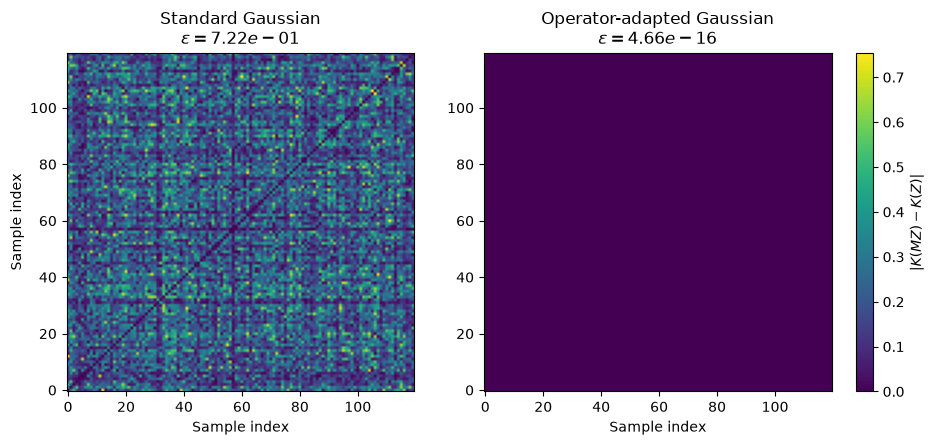

In [61]:
# ============================================================
# FIGURE 4: GRAM MATRIX CHANGE
# ============================================================

D_standard = np.abs(K_standard_after - K_standard_before)
D_adapt = np.abs(K_adapt_after - K_adapt_before)

vmax = D_standard.max()

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))

im1 = axes[0].imshow(
    D_standard,
    origin='lower',
    aspect='auto',
    vmin=0,
    vmax=vmax
)

axes[0].set_title(
    rf'Standard Gaussian'
    '\n'
    rf'$\varepsilon={err_standard:.2e}$'
)

axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Sample index')


im2 = axes[1].imshow(
    D_adapt,
    origin='lower',
    aspect='auto',
    vmin=0,
    vmax=vmax
)

axes[1].set_title(
    rf'Operator-adapted Gaussian'
    '\n'
    rf'$\varepsilon={err_adapt:.2e}$'
)

axes[1].set_xlabel('Sample index')

cbar = fig.colorbar(im2, ax=axes.ravel().tolist(),
                    fraction=0.03, pad=0.03)

cbar.set_label(r'$|K(MZ)-K(Z)|$')

plt.show()

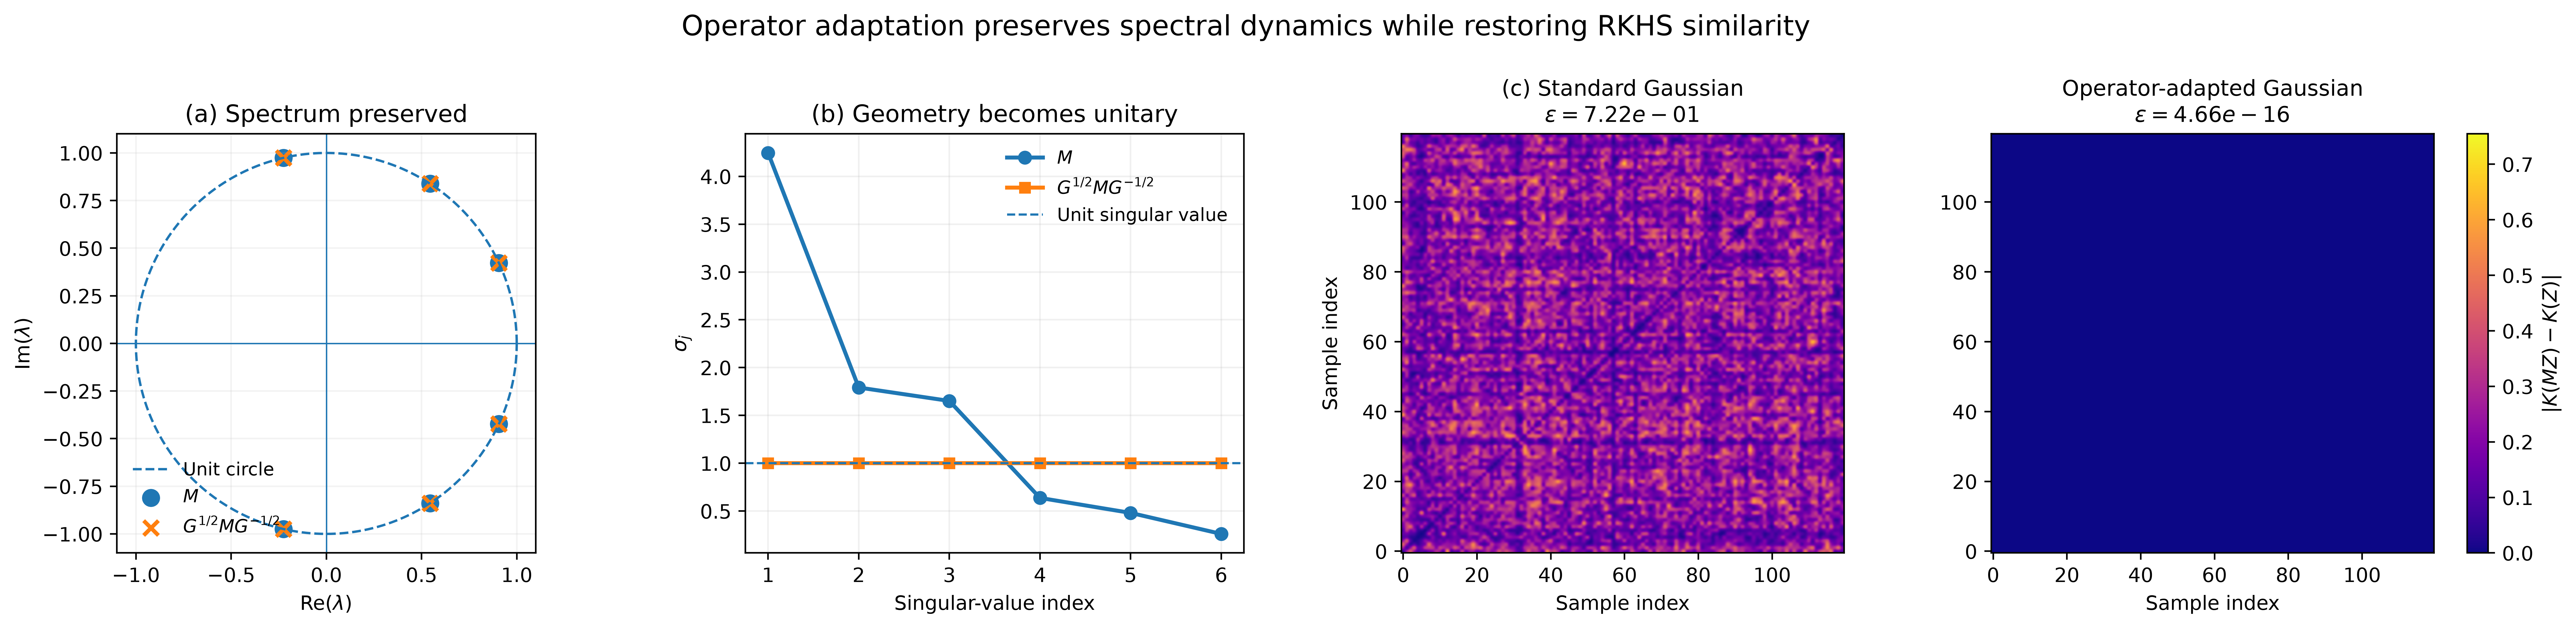

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Assumes these are already available:
# M, G, M_adapt
# Z, MZ
# K_standard_before, K_standard_after
# K_adapt_before, K_adapt_after
# err_standard, err_adapt
# ------------------------------------------------------------

# Spectrum
lam_M = np.linalg.eigvals(M)
lam_adapt = np.linalg.eigvals(M_adapt)

# Singular values
sv_M = np.linalg.svd(M, compute_uv=False)
sv_adapt = np.linalg.svd(M_adapt, compute_uv=False)

# Pairwise similarity changes
D_standard = np.abs(K_standard_after - K_standard_before)
D_adapt = np.abs(K_adapt_after - K_adapt_before)

# IMPORTANT: same scale for both heatmaps
vmax = D_standard.max()

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig = plt.figure(figsize=(22, 3.8),dpi=500)

gs = fig.add_gridspec(
    1, 4,
    width_ratios=[1.05, 1.0, 0.95, 0.95],
    wspace=0.32
)

# ============================================================
# (a) SPECTRUM
# ============================================================

ax1 = fig.add_subplot(gs[0, 0])

theta = np.linspace(0, 2*np.pi, 500)

ax1.plot(
    np.cos(theta),
    np.sin(theta),
    '--',
    linewidth=1.2,
    label='Unit circle'
)

ax1.scatter(
    lam_M.real,
    lam_M.imag,
    s=65,
    marker='o',
    label=r'$M$'
)

ax1.scatter(
    lam_adapt.real,
    lam_adapt.imag,
    s=55,
    marker='x',
    linewidths=2,
    label=r'$G^{1/2}MG^{-1/2}$'
)

ax1.axhline(0, linewidth=0.7)
ax1.axvline(0, linewidth=0.7)

ax1.set_aspect('equal')

ax1.set_xlabel(r'$\mathrm{Re}(\lambda)$')
ax1.set_ylabel(r'$\mathrm{Im}(\lambda)$')

ax1.set_title(
    '(a) Spectrum preserved',
    fontsize=12
)

ax1.legend(
    frameon=False,
    fontsize=9,
    loc='lower left'
)

ax1.grid(alpha=0.15)


# ============================================================
# (b) SINGULAR VALUES
# ============================================================

ax2 = fig.add_subplot(gs[0, 1])

idx = np.arange(1, len(sv_M) + 1)

ax2.plot(
    idx,
    np.sort(sv_M)[::-1],
    'o-',
    linewidth=2,
    markersize=6,
    label=r'$M$'
)

ax2.plot(
    idx,
    np.sort(sv_adapt)[::-1],
    's-',
    linewidth=2,
    markersize=5,
    label=r'$G^{1/2}MG^{-1/2}$'
)

ax2.axhline(
    1,
    linestyle='--',
    linewidth=1.1,
    label='Unit singular value'
)

ax2.set_xlabel('Singular-value index')
ax2.set_ylabel(r'$\sigma_j$')

ax2.set_title(
    '(b) Geometry becomes unitary',
    fontsize=12
)

ax2.grid(alpha=0.18)

ax2.legend(
    frameon=False,
    fontsize=9
)


# ============================================================
# (c1) STANDARD GAUSSIAN
# ============================================================

ax3 = fig.add_subplot(gs[0, 2])

im3 = ax3.imshow(
    D_standard,
    origin='lower',
    aspect='auto',
    vmin=0,
    vmax=vmax,
    interpolation='gaussian',
    cmap='plasma'
)

ax3.set_title(
    '(c) Standard Gaussian\n'
    rf'$\varepsilon={err_standard:.2e}$',
    fontsize=11
)

ax3.set_xlabel('Sample index')
ax3.set_ylabel('Sample index')


# ============================================================
# (c2) OPERATOR-ADAPTED GAUSSIAN
# ============================================================

ax4 = fig.add_subplot(gs[0, 3])

im4 = ax4.imshow(
    D_adapt,
    origin='lower',
    aspect='auto',
    vmin=0,
    vmax=vmax,
    cmap='plasma',
    interpolation='gaussian'
)

ax4.set_title(
    'Operator-adapted Gaussian\n'
    rf'$\varepsilon={err_adapt:.2e}$',
    fontsize=11
)

ax4.set_xlabel('Sample index')

# shared colorbar
cbar = fig.colorbar(
    im4,
    ax=[ax3, ax4],
    fraction=0.035,
    pad=0.03
)

cbar.set_label(
    r'$|K(MZ)-K(Z)|$'
)

# ------------------------------------------------------------
# Overall annotation
# ------------------------------------------------------------

fig.suptitle(
    'Operator adaptation preserves spectral dynamics while restoring RKHS similarity',
    fontsize=14,
    y=1.1
)

plt.show()

In [64]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# ============================================================
# 1. CONSTRUCT A NON-ORTHOGONAL BUT UNITARIZABLE OPERATOR
#    Dimension d = 20
# ============================================================

def rotation(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

# ------------------------------------------------------------
# 10 independent planar rotations -> 20-dimensional Q
# ------------------------------------------------------------

angles = np.deg2rad([
    12, 27, 41, 58, 76,
    97, 123, 149, 171, 203
])

d = 2 * len(angles)

Q = np.zeros((d, d))

for k, theta in enumerate(angles):
    Q[2*k:2*k+2, 2*k:2*k+2] = rotation(theta)

# Q is orthogonal
print("dimension d =", d)
print("||Q^T Q - I||_F =",
      np.linalg.norm(Q.T @ Q - np.eye(d), ord='fro'))


# ============================================================
# 2. NON-ORTHOGONAL CHANGE OF COORDINATES
# ============================================================

# Start from identity
S = np.eye(d)

# Add controlled upper-triangular mixing
for i in range(d - 1):
    S[i, i + 1] = 0.45 + 0.35 * np.random.rand()

# Some longer-range couplings
for i in range(d - 3):
    S[i, i + 3] += 0.20 * np.random.randn()

for i in range(d - 5):
    S[i, i + 5] += 0.12 * np.random.randn()

# ------------------------------------------------------------
# Same underlying unitary dynamics,
# represented in a non-orthogonal coordinate system
# ------------------------------------------------------------

Sinv = np.linalg.inv(S)

M = S @ Q @ Sinv

# ============================================================
# 3. OPERATOR-ADAPTED METRIC
# ============================================================

G = Sinv.T @ Sinv

# ============================================================
# 4. VERIFY THE INVARIANT METRIC EQUATION
# ============================================================

residual = np.linalg.norm(
    M.T @ G @ M - G,
    ord='fro'
)

nonunitary_residual = np.linalg.norm(
    M.T @ M - np.eye(d),
    ord='fro'
)

print("\n=== Operator checks ===")
print("||M^T G M - G||_F =", residual)
print("||M^T M - I||_F   =", nonunitary_residual)

print("\nCondition numbers")
print("cond(S) =", np.linalg.cond(S))
print("cond(G) =", np.linalg.cond(G))

dimension d = 20
||Q^T Q - I||_F = 5.703939042625236e-16

=== Operator checks ===
||M^T G M - G||_F = 2.838699372790763e-15
||M^T M - I||_F   = 9.290679351704906

Condition numbers
cond(S) = 4.713017052505091
cond(G) = 22.212529737203774


In [65]:
# ============================================================
# 5. COMPUTE G^{1/2} AND G^{-1/2}
# ============================================================

evals_G, evecs_G = np.linalg.eigh(G)

Ghalf = (
    evecs_G
    @ np.diag(np.sqrt(evals_G))
    @ evecs_G.T
)

Gmhalf = (
    evecs_G
    @ np.diag(1.0 / np.sqrt(evals_G))
    @ evecs_G.T
)

M_adapt = Ghalf @ M @ Gmhalf

adapted_unitarity_residual = np.linalg.norm(
    M_adapt.T @ M_adapt - np.eye(d),
    ord='fro'
)

print("\n=== Adapted operator ===")
print("||M_adapt^T M_adapt - I||_F =",
      adapted_unitarity_residual)


=== Adapted operator ===
||M_adapt^T M_adapt - I||_F = 1.6879121265824255e-14


In [66]:
# ============================================================
# 6. SPECTRUM AND SINGULAR VALUES
# ============================================================

lam_M = np.linalg.eigvals(M)
lam_adapt = np.linalg.eigvals(M_adapt)

sv_M = np.linalg.svd(M, compute_uv=False)
sv_adapt = np.linalg.svd(M_adapt, compute_uv=False)

print("\nMax eigenvalue modulus deviation from 1:")
print(
    np.max(np.abs(np.abs(lam_M) - 1.0))
)

print("\nSingular values of M:")
print(np.sort(sv_M)[::-1])

print("\nSingular values of adapted operator:")
print(np.sort(sv_adapt)[::-1])


Max eigenvalue modulus deviation from 1:
2.220446049250313e-16

Singular values of M:
[2.62870648 2.50702717 2.04179492 1.93143154 1.44315043 1.37564809
 1.29843447 1.16781115 1.10434258 1.07177922 1.04044385 0.94979783
 0.91972463 0.78913508 0.73177995 0.67576982 0.56194096 0.49542174
 0.35011855 0.31236869]

Singular values of adapted operator:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [67]:
# ============================================================
# 7. SAMPLE POINTS FOR RKHS SIMILARITY TEST
# ============================================================

Npts = 120

Z = np.random.randn(Npts, d)

MZ = Z @ M.T


def gaussian_gram(X, metric, sigma=3.0):

    diff = X[:, None, :] - X[None, :, :]

    D2 = np.einsum(
        '...i,ij,...j->...',
        diff,
        metric,
        diff
    )

    return np.exp(
        -D2 / (2 * sigma**2)
    )


sigma = 3.0

K_standard_before = gaussian_gram(
    Z,
    np.eye(d),
    sigma
)

K_standard_after = gaussian_gram(
    MZ,
    np.eye(d),
    sigma
)

K_adapt_before = gaussian_gram(
    Z,
    G,
    sigma
)

K_adapt_after = gaussian_gram(
    MZ,
    G,
    sigma
)

err_standard = (
    np.linalg.norm(
        K_standard_after - K_standard_before,
        ord='fro'
    )
    /
    np.linalg.norm(
        K_standard_before,
        ord='fro'
    )
)

err_adapt = (
    np.linalg.norm(
        K_adapt_after - K_adapt_before,
        ord='fro'
    )
    /
    np.linalg.norm(
        K_adapt_before,
        ord='fro'
    )
)

print("\n=== Kernel similarity errors ===")
print("Standard Gaussian error =", err_standard)
print("Adapted Gaussian error  =", err_adapt)


=== Kernel similarity errors ===
Standard Gaussian error = 0.5613232885172924
Adapted Gaussian error  = 1.1205512898105809e-15


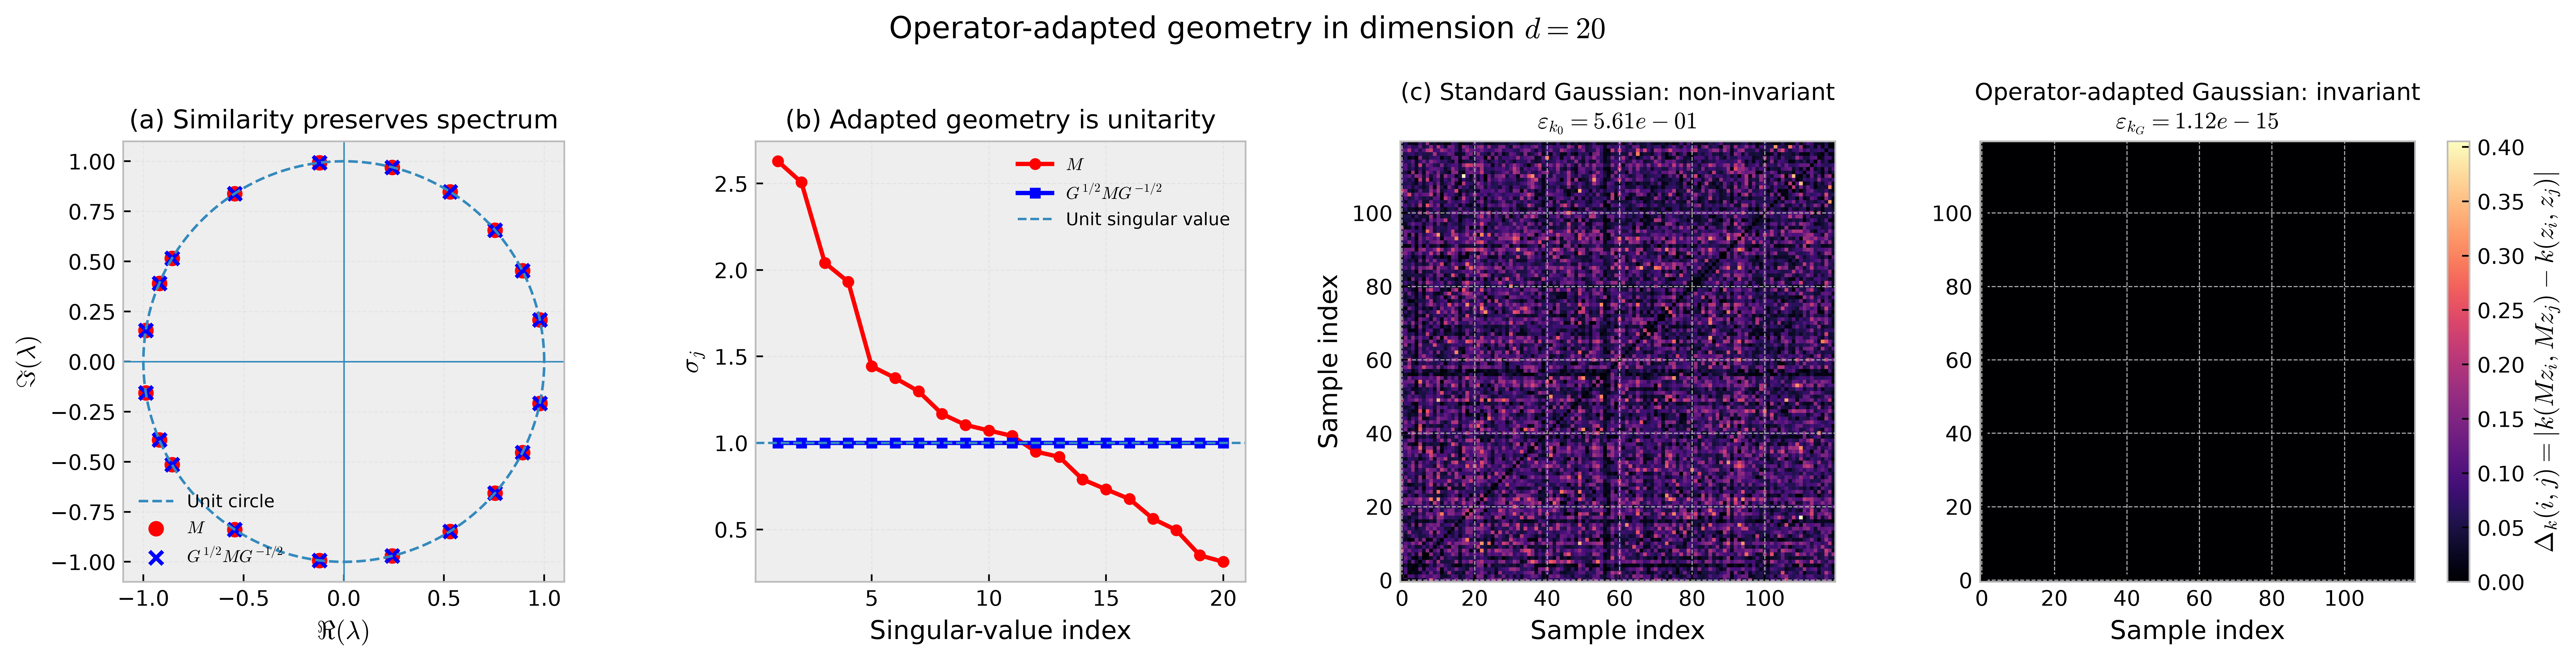

In [144]:
# ============================================================
# 8. FINAL COMPOSITE FIGURE
# ============================================================

D_standard = np.abs(
    K_standard_after - K_standard_before
)

D_adapt = np.abs(
    K_adapt_after - K_adapt_before
)

vmax = D_standard.max()

fig = plt.figure(figsize=(20, 3.7), dpi=500)

gs = fig.add_gridspec(
    1, 4,
    width_ratios=[1.05, 1.0, 0.95, 0.95],
    wspace=0.32
)

# ------------------------------------------------------------
# (a) Spectrum
# ------------------------------------------------------------

ax1 = fig.add_subplot(gs[0, 0])

theta = np.linspace(
    0,
    2*np.pi,
    500
)

ax1.plot(
    np.cos(theta),
    np.sin(theta),
    '--',
    linewidth=1.2,
    label='Unit circle'
)

ax1.scatter(
    lam_M.real,
    lam_M.imag,
    s=45,
    marker='o',
    label=r'$M$',
    color='red'
)

ax1.scatter(
    lam_adapt.real,
    lam_adapt.imag,
    s=38,
    marker='x',
    linewidths=1.8,
    label=r'$G^{1/2}MG^{-1/2}$',
    color='blue'
)

ax1.axhline(0, linewidth=0.7)
ax1.axvline(0, linewidth=0.7)

ax1.set_aspect('equal')

ax1.set_xlabel(
    r'$\Re(\lambda)$'
)

ax1.set_ylabel(
    r'$\Im(\lambda)$'
)

ax1.set_title(
    '(a) Similarity preserves spectrum',
    fontsize=12
)

ax1.legend(
    frameon=False,
    fontsize=8,
    loc='lower left'
)

ax1.grid(alpha=0.15)


# ------------------------------------------------------------
# (b) Singular values
# ------------------------------------------------------------

ax2 = fig.add_subplot(gs[0, 1])

idx = np.arange(
    1,
    d + 1
)

ax2.plot(
    idx,
    np.sort(sv_M)[::-1],
    'o-',
    linewidth=2,
    markersize=4.5,
    label=r'$M$',
    color='red'
)

ax2.plot(
    idx,
    np.sort(sv_adapt)[::-1],
    's-',
    linewidth=2,
    markersize=4,
    label=r'$G^{1/2}MG^{-1/2}$',
    color='blue'
)

ax2.axhline(
    1.0,
    linestyle='--',
    linewidth=1.1,
    label='Unit singular value'
)

ax2.set_xlabel(
    'Singular-value index'
)

ax2.set_ylabel(
    r'$\sigma_j$'
)

ax2.set_title(
    '(b) Adapted geometry is unitarity',
    fontsize=12
)

ax2.grid(alpha=0.18)

ax2.legend(
    frameon=False,
    fontsize=8
)


# ------------------------------------------------------------
# (c1) Standard Gaussian
# ------------------------------------------------------------

ax3 = fig.add_subplot(gs[0, 2])

im3 = ax3.imshow(
    D_standard,
    origin='lower',
    aspect='auto',
    vmin=0,
    vmax=vmax,
    cmap='magma',
    interpolation='None'
)

ax3.set_title(
    '(c) Standard Gaussian: non-invariant\n'
    rf'$\varepsilon_{{k_0}}={err_standard:.2e}$',
    fontsize=11
)

ax3.set_xlabel(
    'Sample index'
)

ax3.set_ylabel(
    'Sample index'
)


# ------------------------------------------------------------
# (c2) Adapted Gaussian
# ------------------------------------------------------------

ax4 = fig.add_subplot(gs[0, 3])

im4 = ax4.imshow(
    D_adapt,
    origin='lower',
    aspect='auto',
    vmin=0,
    vmax=vmax,
    cmap='magma',
    interpolation='gaussian'
)

ax4.set_title(
    'Operator-adapted Gaussian: invariant\n'
    rf'$\varepsilon_{{k_G}}={err_adapt:.2e}$',
    fontsize=11
)

ax4.set_xlabel(
    'Sample index'
)

cbar = fig.colorbar(
    im4,
    ax=[ax3, ax4],
    fraction=0.035,
    pad=0.03
)

cbar.set_label(
    r'$\Delta_k(i,j)=|k(Mz_i,Mz_j)-k(z_i,z_j)|$'
)

fig.suptitle(
    'Operator-adapted geometry in dimension $d=20$',
    fontsize=14,
    y=1.1
)

plt.show()

Dimension d = 20
||Q^T Q - I||_F = 5.703939042625236e-16

=== Original operator ===
||M^T G M - G||_F = 2.838699372790763e-15
||M^T M - I||_F   = 9.290679351704906

Condition numbers:
cond(S) = 4.713017052505091
cond(G) = 22.212529737203774

=== Adapted operator ===
||M_adapt^T M_adapt - I||_F = 1.6879121265824255e-14

=== Spectrum ===
Max | |lambda(M)| - 1 | = 2.220446049250313e-16
Max eigenvalue-set difference (sorted moduli) = 1.1102230246251565e-15

=== Singular values ===
Original singular values:
 [2.62870648 2.50702717 2.04179492 1.93143154 1.44315043 1.37564809
 1.29843447 1.16781115 1.10434258 1.07177922 1.04044385 0.94979783
 0.91972463 0.78913508 0.73177995 0.67576982 0.56194096 0.49542174
 0.35011855 0.31236869]

Adapted singular values:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Max adapted singular-value deviation from 1 = 1.9984014443252818e-15

=== Pairwise similarity preservation ===
Standard Gaussian relative Gram error = 0.5613232885172924
Adapte

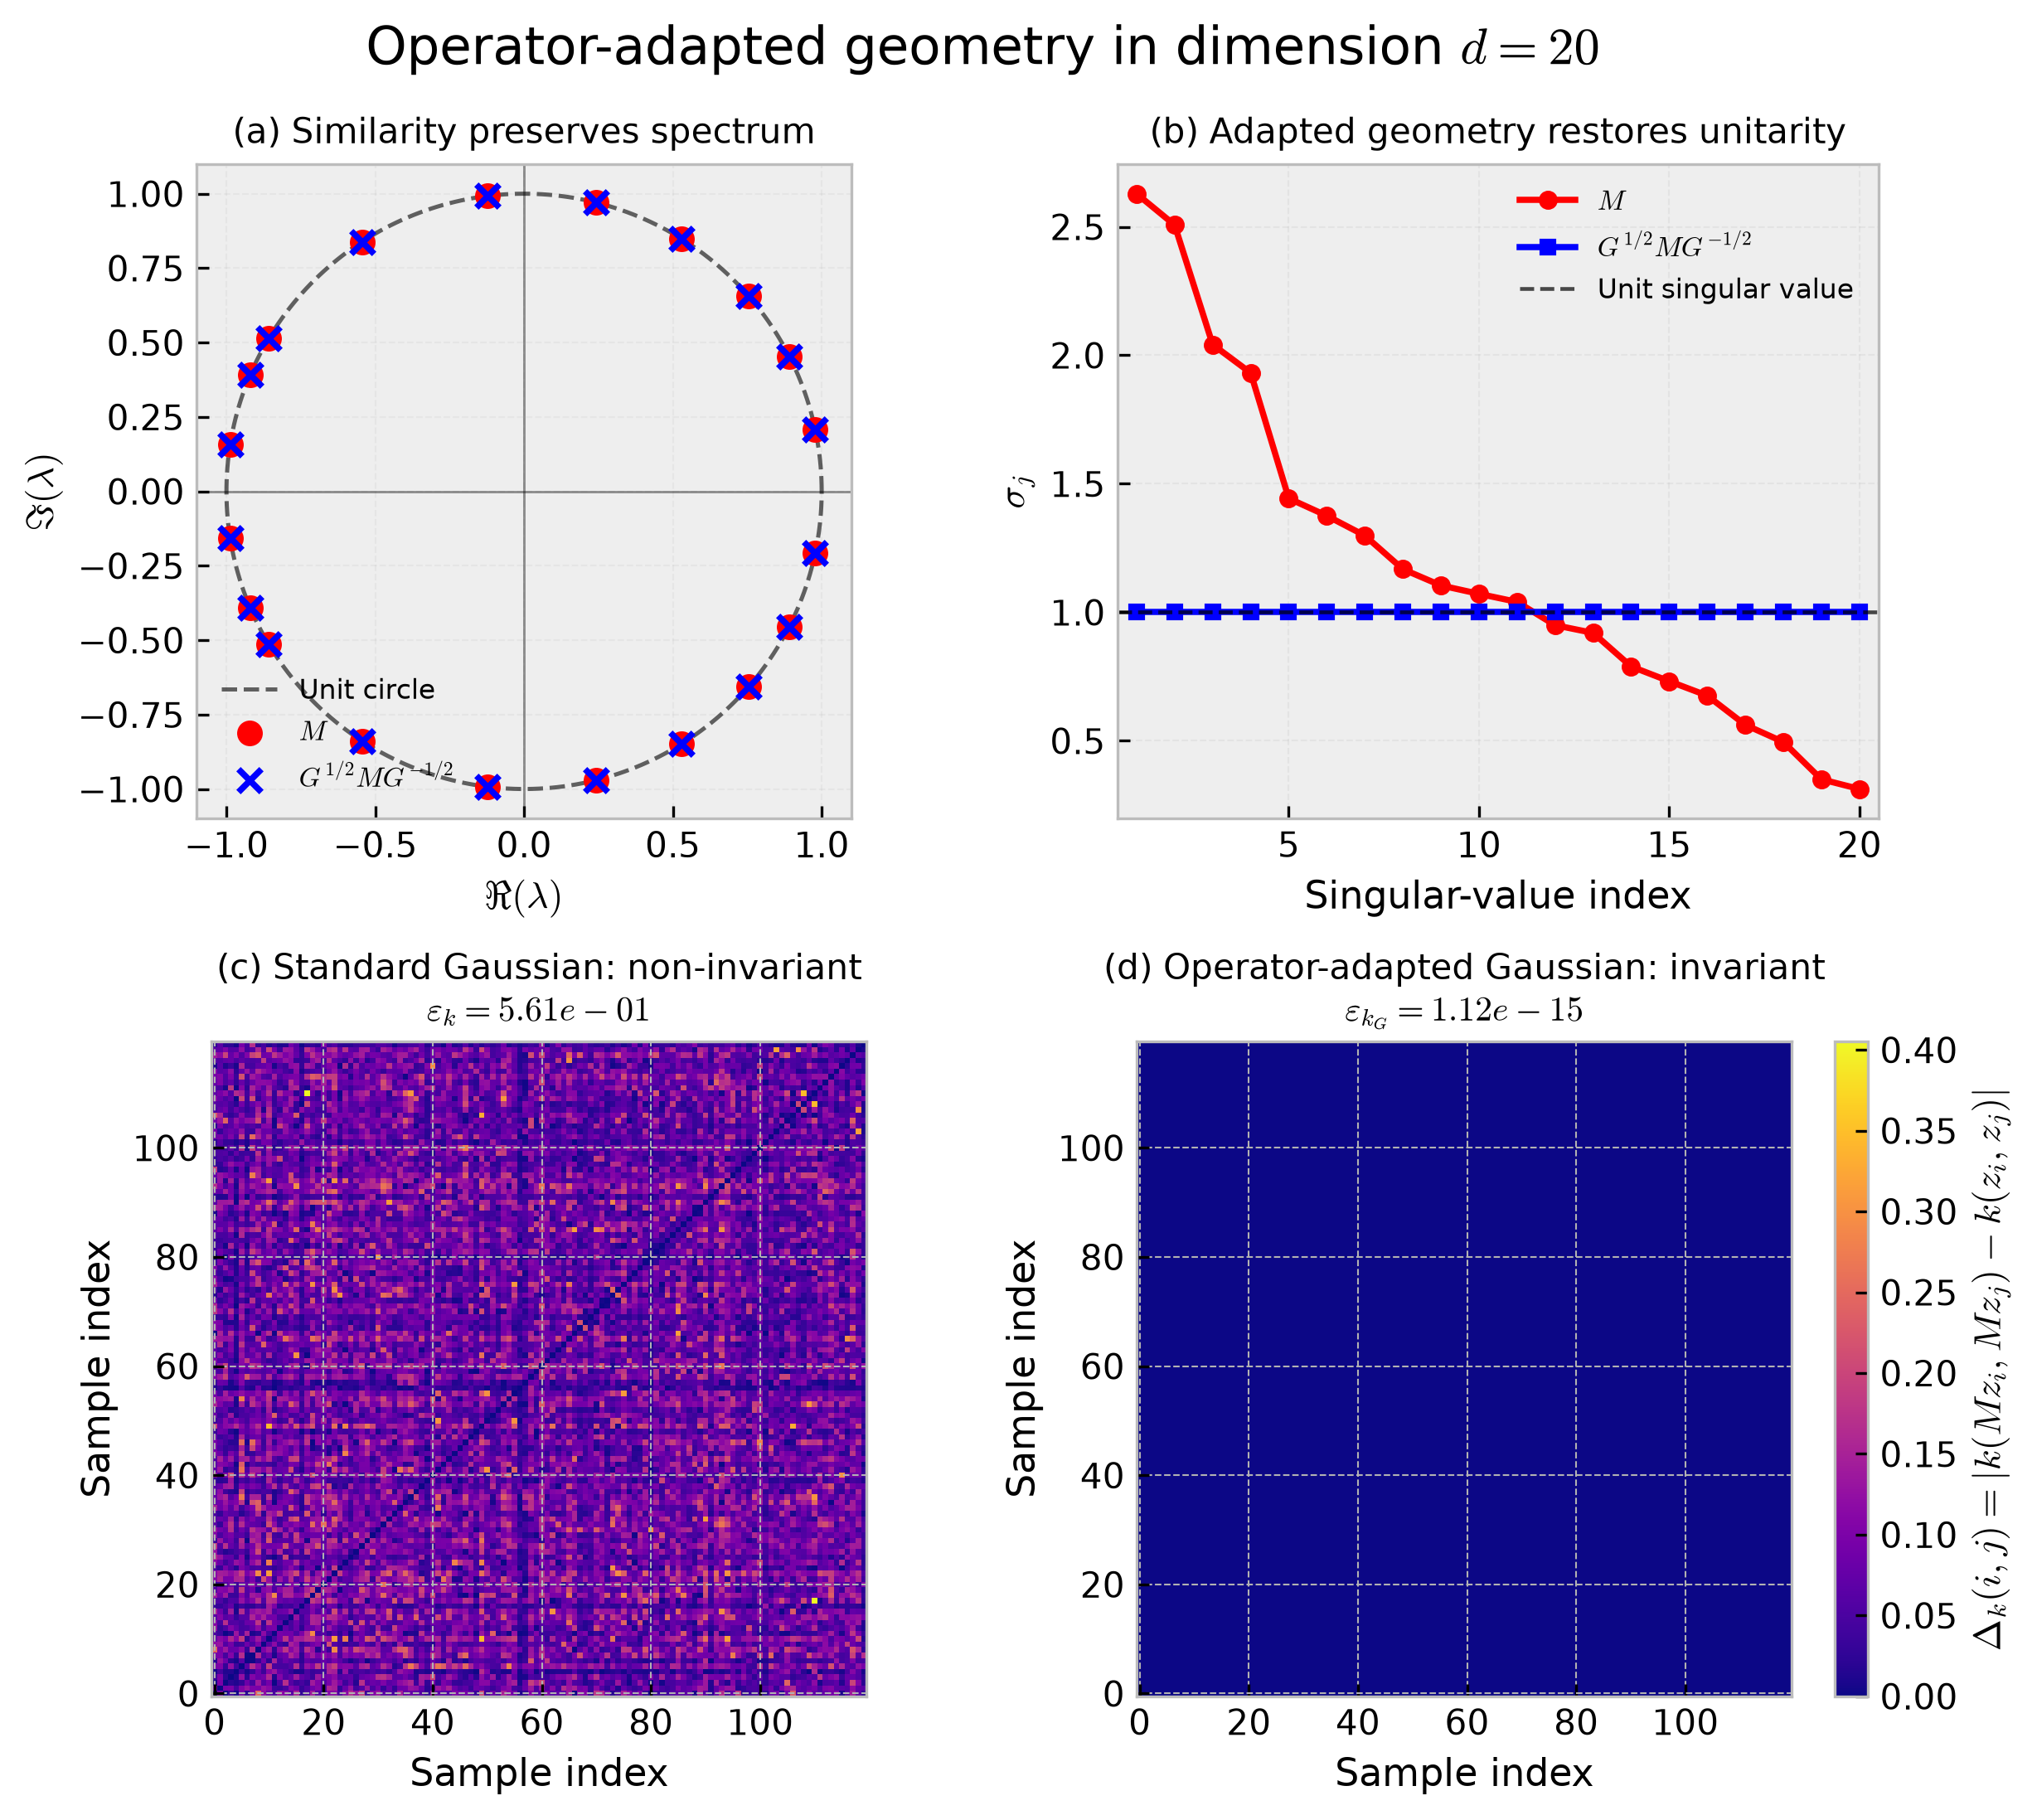

In [130]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# ============================================================
# 1. CONSTRUCT A NON-ORTHOGONAL BUT UNITARIZABLE OPERATOR
#    Dimension d = 20
# ============================================================

def rotation(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

# 10 planar rotations -> 20-dimensional orthogonal operator Q
angles = np.deg2rad([
    12, 27, 41, 58, 76,
    97, 123, 149, 171, 203
])

d = 2 * len(angles)

Q = np.zeros((d, d))

for k, theta in enumerate(angles):
    Q[2*k:2*k+2, 2*k:2*k+2] = rotation(theta)

print("Dimension d =", d)

orthogonality_residual = np.linalg.norm(
    Q.T @ Q - np.eye(d),
    ord='fro'
)

print("||Q^T Q - I||_F =", orthogonality_residual)


# ============================================================
# 2. NON-ORTHOGONAL CHANGE OF COORDINATES
# ============================================================

S = np.eye(d)

# Moderate nearest-neighbor mixing
for i in range(d - 1):
    S[i, i + 1] = 0.45 + 0.35 * np.random.rand()

# Longer-range mixing
for i in range(d - 3):
    S[i, i + 3] += 0.20 * np.random.randn()

for i in range(d - 5):
    S[i, i + 5] += 0.12 * np.random.randn()

# Inverse
Sinv = np.linalg.inv(S)

# Same underlying operator in non-orthogonal coordinates
M = S @ Q @ Sinv


# ============================================================
# 3. OPERATOR-ADAPTED METRIC
# ============================================================

G = Sinv.T @ Sinv


# ============================================================
# 4. VERIFY M^T G M = G
# ============================================================

metric_residual = np.linalg.norm(
    M.T @ G @ M - G,
    ord='fro'
)

euclidean_nonunitarity = np.linalg.norm(
    M.T @ M - np.eye(d),
    ord='fro'
)

print("\n=== Original operator ===")
print("||M^T G M - G||_F =", metric_residual)
print("||M^T M - I||_F   =", euclidean_nonunitarity)

print("\nCondition numbers:")
print("cond(S) =", np.linalg.cond(S))
print("cond(G) =", np.linalg.cond(G))


# ============================================================
# 5. COMPUTE G^{1/2} AND G^{-1/2}
# ============================================================

evals_G, evecs_G = np.linalg.eigh(G)

# Safety check
if np.any(evals_G <= 0):
    raise ValueError("G is not positive definite.")

Ghalf = (
    evecs_G
    @ np.diag(np.sqrt(evals_G))
    @ evecs_G.T
)

Gmhalf = (
    evecs_G
    @ np.diag(1.0 / np.sqrt(evals_G))
    @ evecs_G.T
)

# Operator represented in coordinates where G becomes Euclidean
M_adapt = Ghalf @ M @ Gmhalf

adapted_unitarity_residual = np.linalg.norm(
    M_adapt.T @ M_adapt - np.eye(d),
    ord='fro'
)

print("\n=== Adapted operator ===")
print(
    "||M_adapt^T M_adapt - I||_F =",
    adapted_unitarity_residual
)


# ============================================================
# 6. EIGENVALUES AND SINGULAR VALUES
# ============================================================

lam_M = np.linalg.eigvals(M)
lam_adapt = np.linalg.eigvals(M_adapt)

sv_M = np.linalg.svd(
    M,
    compute_uv=False
)

sv_adapt = np.linalg.svd(
    M_adapt,
    compute_uv=False
)

print("\n=== Spectrum ===")

print(
    "Max | |lambda(M)| - 1 | =",
    np.max(np.abs(np.abs(lam_M) - 1.0))
)

print(
    "Max eigenvalue-set difference (sorted moduli) =",
    np.max(
        np.abs(
            np.sort(np.abs(lam_M))
            -
            np.sort(np.abs(lam_adapt))
        )
    )
)

print("\n=== Singular values ===")

print(
    "Original singular values:\n",
    np.sort(sv_M)[::-1]
)

print(
    "\nAdapted singular values:\n",
    np.sort(sv_adapt)[::-1]
)

print(
    "\nMax adapted singular-value deviation from 1 =",
    np.max(np.abs(sv_adapt - 1.0))
)


# ============================================================
# 7. SAMPLE POINTS FOR RKHS SIMILARITY
# ============================================================

Npts = 120

Z = np.random.randn(
    Npts,
    d
)

# Apply M to all row-vector samples
MZ = Z @ M.T


# ============================================================
# 8. GAUSSIAN GRAM MATRIX
# ============================================================

def gaussian_gram(X, metric, sigma=3.0):

    diff = (
        X[:, None, :]
        -
        X[None, :, :]
    )

    D2 = np.einsum(
        '...i,ij,...j->...',
        diff,
        metric,
        diff
    )

    # Small negative values can appear numerically
    D2 = np.maximum(D2, 0.0)

    return np.exp(
        -D2 / (2.0 * sigma**2)
    )


sigma_kernel = 3.0


# ============================================================
# 9. STANDARD GAUSSIAN
# ============================================================

K_standard_before = gaussian_gram(
    Z,
    np.eye(d),
    sigma_kernel
)

K_standard_after = gaussian_gram(
    MZ,
    np.eye(d),
    sigma_kernel
)


# ============================================================
# 10. OPERATOR-ADAPTED GAUSSIAN
# ============================================================

K_adapt_before = gaussian_gram(
    Z,
    G,
    sigma_kernel
)

K_adapt_after = gaussian_gram(
    MZ,
    G,
    sigma_kernel
)


# ============================================================
# 11. RELATIVE GRAM-MATRIX ERRORS
# ============================================================

err_standard = (
    np.linalg.norm(
        K_standard_after
        -
        K_standard_before,
        ord='fro'
    )
    /
    np.linalg.norm(
        K_standard_before,
        ord='fro'
    )
)

err_adapt = (
    np.linalg.norm(
        K_adapt_after
        -
        K_adapt_before,
        ord='fro'
    )
    /
    np.linalg.norm(
        K_adapt_before,
        ord='fro'
    )
)

print("\n=== Pairwise similarity preservation ===")

print(
    "Standard Gaussian relative Gram error =",
    err_standard
)

print(
    "Adapted Gaussian relative Gram error  =",
    err_adapt
)


# ============================================================
# 12. DIFFERENCE MATRICES
# ============================================================

D_standard = np.abs(
    K_standard_after
    -
    K_standard_before
)

D_adapt = np.abs(
    K_adapt_after
    -
    K_adapt_before
)

# Same scale for both heatmaps
vmax = D_standard.max()


# ============================================================
# 13. FINAL COMPOSITE FIGURE — 2 x 2
# ============================================================

fig = plt.figure(
    figsize=(9.0, 8.0),
    dpi=300
)

gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[1, 1],
    height_ratios=[1, 1],
    wspace=0.28,
    hspace=0.34
)


# ============================================================
# (a) SPECTRUM
# ============================================================

ax1 = fig.add_subplot(
    gs[0, 0]
)

theta = np.linspace(
    0,
    2*np.pi,
    600
)

ax1.plot(
    np.cos(theta),
    np.sin(theta),
    '--',
    linewidth=1.2,
    color='black',
    alpha=0.60,
    label='Unit circle'
)

ax1.scatter(
    lam_M.real,
    lam_M.imag,
    s=48,
    marker='o',
    color='red',
    label=r'$M$',
    zorder=3
)

ax1.scatter(
    lam_adapt.real,
    lam_adapt.imag,
    s=44,
    marker='x',
    linewidths=1.8,
    color='blue',
    label=r'$G^{1/2}MG^{-1/2}$',
    zorder=4
)

ax1.axhline(
    0,
    linewidth=0.7,
    color='black',
    alpha=0.40
)

ax1.axvline(
    0,
    linewidth=0.7,
    color='black',
    alpha=0.40
)

ax1.set_aspect(
    'equal'
)

ax1.set_xlim(
    -1.1,
    1.1
)

ax1.set_ylim(
    -1.1,
    1.1
)

ax1.set_xlabel(
    r'$\Re(\lambda)$',
    fontsize=11
)

ax1.set_ylabel(
    r'$\Im(\lambda)$',
    fontsize=11
)

ax1.set_title(
    '(a) Similarity preserves spectrum',
    fontsize=10
)

ax1.legend(
    frameon=False,
    fontsize=8,
    loc='lower left'
)

ax1.grid(
    alpha=0.15
)


# ============================================================
# (b) SINGULAR VALUES
# ============================================================

ax2 = fig.add_subplot(
    gs[0, 1]
)

idx = np.arange(
    1,
    d + 1
)

ax2.plot(
    idx,
    np.sort(sv_M)[::-1],
    'o-',
    linewidth=1.8,
    markersize=4.5,
    color='red',
    label=r'$M$'
)

ax2.plot(
    idx,
    np.sort(sv_adapt)[::-1],
    's-',
    linewidth=1.8,
    markersize=4.0,
    color='blue',
    label=r'$G^{1/2}MG^{-1/2}$'
)

ax2.axhline(
    1.0,
    linestyle='--',
    linewidth=1.1,
    color='black',
    alpha=0.70,
    label='Unit singular value'
)

ax2.set_xlim(
    0.5,
    d + 0.5
)

ax2.set_xlabel(
    'Singular-value index',
    fontsize=11
)

ax2.set_ylabel(
    r'$\sigma_j$',
    fontsize=11
)

ax2.set_title(
    '(b) Adapted geometry restores unitarity',
    fontsize=10
)

ax2.legend(
    frameon=False,
    fontsize=8,
    loc='upper right'
)

ax2.grid(
    alpha=0.18
)


# ============================================================
# (c) STANDARD GAUSSIAN
# ============================================================

ax3 = fig.add_subplot(
    gs[1, 0]
)

im3 = ax3.imshow(
    D_standard,
    origin='lower',
    aspect='equal',
    vmin=0,
    vmax=vmax,
    cmap='plasma',
    interpolation='nearest'
)

ax3.set_title(
    '(c) Standard Gaussian: non-invariant\n'
    rf'$\varepsilon_k={err_standard:.2e}$',
    fontsize=10
)

ax3.set_xlabel(
    'Sample index',
    fontsize=11
)

ax3.set_ylabel(
    'Sample index',
    fontsize=11
)


# ============================================================
# (d) OPERATOR-ADAPTED GAUSSIAN
# ============================================================

ax4 = fig.add_subplot(
    gs[1, 1]
)

im4 = ax4.imshow(
    D_adapt,
    origin='lower',
    aspect='equal',
    vmin=0,
    vmax=vmax,
    cmap='plasma',
    interpolation='nearest'
)

ax4.set_title(
    '(d) Operator-adapted Gaussian: invariant\n'
    rf'$\varepsilon_{{k_G}}={err_adapt:.2e}$',
    fontsize=10
)

ax4.set_xlabel(
    'Sample index',
    fontsize=11
)

ax4.set_ylabel(
    'Sample index',
    fontsize=11
)


# ============================================================
# 14. SHARED COLORBAR
# ============================================================

cbar = fig.colorbar(
    im4,
    ax=[ax3, ax4],
    orientation='vertical',
    fraction=0.025,
    pad=0.025
)

cbar.set_label(
    r'$\Delta_k(i,j)=|k(Mz_i,Mz_j)-k(z_i,z_j)|$',
    fontsize=11
)


# ============================================================
# 15. GLOBAL TITLE
# ============================================================

fig.suptitle(
    r'Operator-adapted geometry in dimension $d=20$',
    fontsize=15,
    y=0.95
)

plt.show()

In [107]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# ============================================================
# 1. VISCOUS BURGERS EQUATION
#
#       u_t + u u_x = nu u_xx
#
# periodic domain x in [0, 2*pi)
# ============================================================

N = 256
L = 2 * np.pi

x = np.linspace(
    0,
    L,
    N,
    endpoint=False
)

dx = L / N

nu = 0.02

dt = 2.5e-3
Tfinal = 4.0

nsteps = int(Tfinal / dt)

# Save every nsave steps
nsave = 10

# ------------------------------------------------------------
# Fourier wave numbers
# ------------------------------------------------------------

k = np.fft.fftfreq(
    N,
    d=dx
) * 2 * np.pi


# ============================================================
# 2. INITIAL CONDITION
# ============================================================

u0 = (
    np.sin(x)
    + 0.5 * np.sin(2*x)
    + 0.25 * np.cos(3*x)
)

u = u0.copy()


# ============================================================
# 3. RHS USING FOURIER DIFFERENTIATION
# ============================================================

def burgers_rhs(u, nu, k):

    uhat = np.fft.fft(u)

    ux = np.fft.ifft(
        1j * k * uhat
    ).real

    uxx = np.fft.ifft(
        -(k**2) * uhat
    ).real

    return (
        -u * ux
        + nu * uxx
    )


# ============================================================
# 4. RK4 TIME INTEGRATION
# ============================================================

snapshots = []
times = []

for n in range(nsteps + 1):

    if n % nsave == 0:
        snapshots.append(u.copy())
        times.append(n * dt)

    k1 = burgers_rhs(
        u,
        nu,
        k
    )

    k2 = burgers_rhs(
        u + 0.5 * dt * k1,
        nu,
        k
    )

    k3 = burgers_rhs(
        u + 0.5 * dt * k2,
        nu,
        k
    )

    k4 = burgers_rhs(
        u + dt * k3,
        nu,
        k
    )

    u = (
        u
        + dt / 6.0
        * (
            k1
            + 2*k2
            + 2*k3
            + k4
        )
    )

snapshots = np.array(
    snapshots
).T

times = np.array(times)

print("Snapshot matrix shape:",
      snapshots.shape)

Snapshot matrix shape: (256, 161)


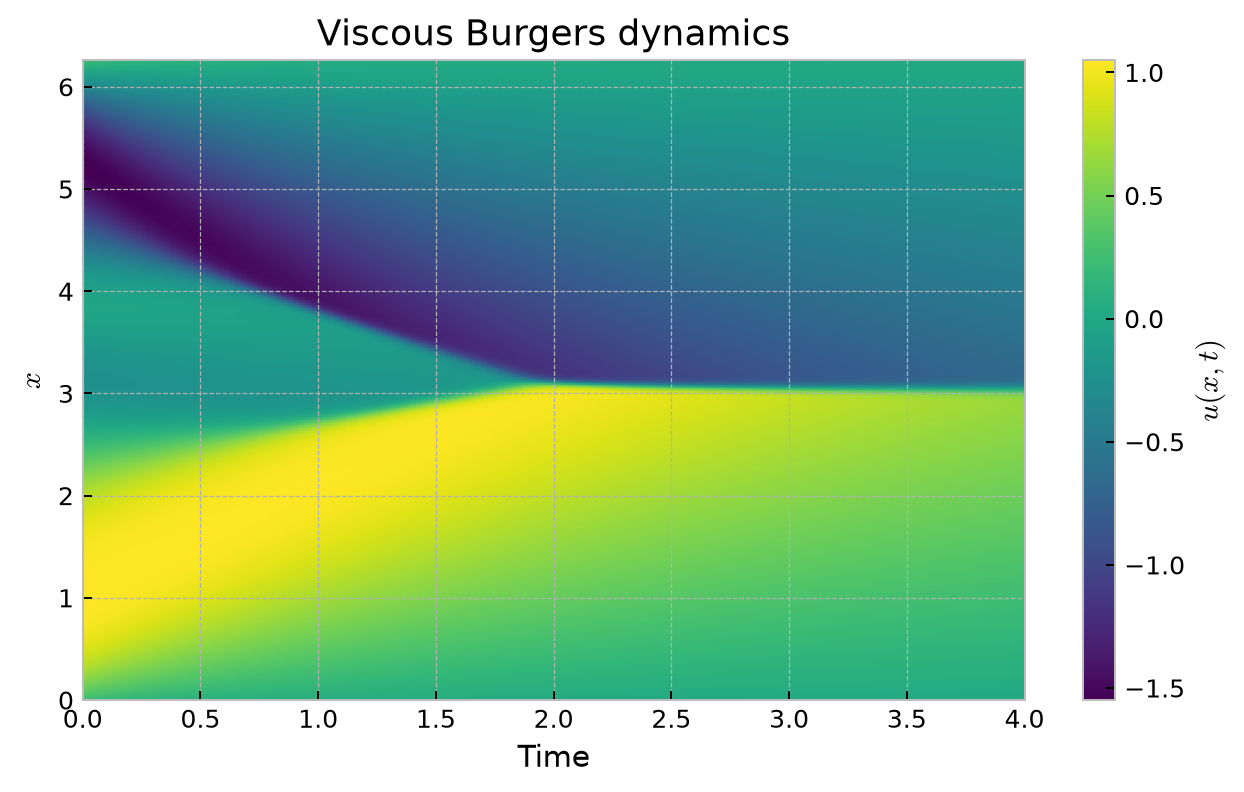

In [108]:
# ============================================================
# 5. BURGERS SPACE-TIME EVOLUTION
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.2, 4.5),
    dpi=180
)

im = ax.imshow(
    snapshots,
    origin='lower',
    aspect='auto',
    extent=[
        times[0],
        times[-1],
        x[0],
        x[-1]
    ],
    cmap='viridis'
)

ax.set_xlabel(
    'Time'
)

ax.set_ylabel(
    r'$x$'
)

ax.set_title(
    'Viscous Burgers dynamics'
)

cbar = plt.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    r'$u(x,t)$'
)

plt.tight_layout()
plt.show()

In [109]:
# ============================================================
# 6. SNAPSHOT PAIRS
# ============================================================

X = snapshots[:, :-1]
Y = snapshots[:, 1:]


# ============================================================
# 7. POD REDUCTION
# ============================================================

U, s, Vh = np.linalg.svd(
    X,
    full_matrices=False
)

# Reduced dimension
r = 20

Ur = U[:, :r]

# Reduced coordinates
Xr = Ur.T @ X
Yr = Ur.T @ Y

print(
    "Reduced snapshot dimension:",
    Xr.shape
)

Reduced snapshot dimension: (20, 160)


In [110]:
# ============================================================
# 8. DATA-DRIVEN LINEAR OPERATOR
# ============================================================

Mr = (
    Yr
    @ np.linalg.pinv(Xr)
)

print(
    "DMD operator shape:",
    Mr.shape
)

DMD operator shape: (20, 20)


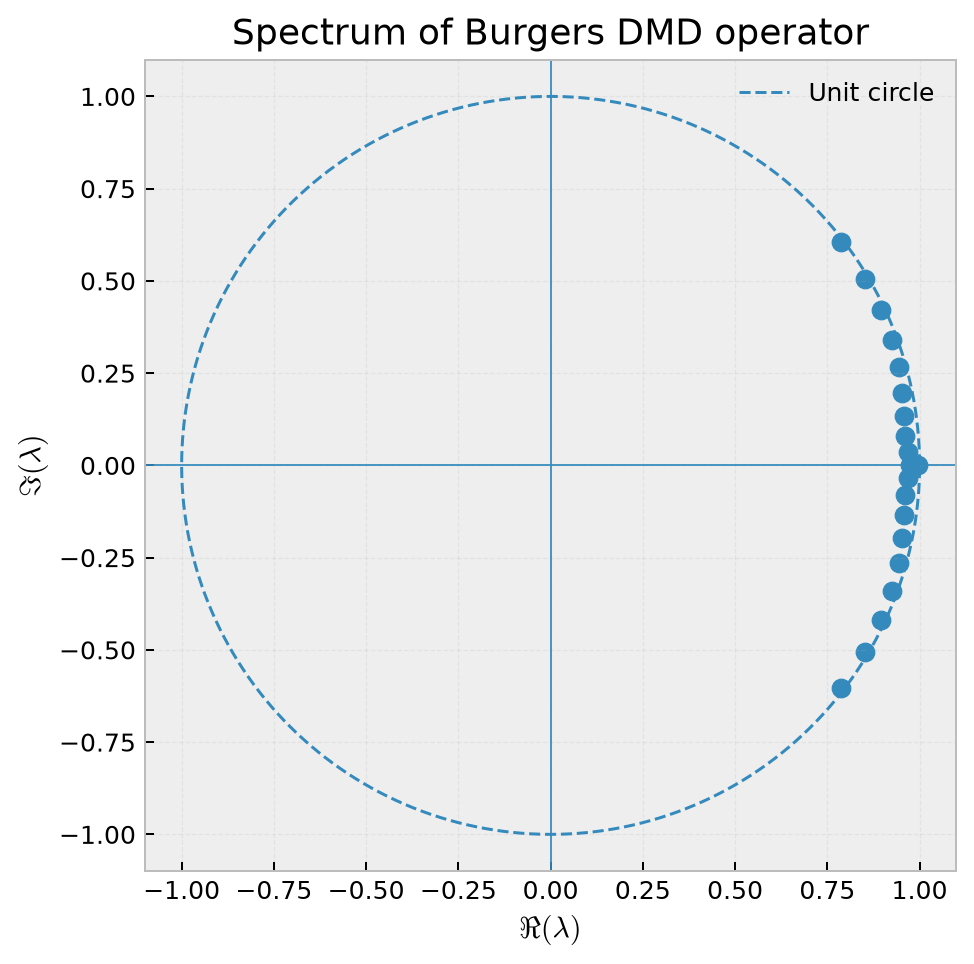

Eigenvalue moduli:
[0.99436782 0.99170229 0.99170229 0.99145242 0.99145242 0.98994119
 0.98994119 0.98660113 0.98660113 0.98077728 0.98077728 0.97343568
 0.97343568 0.9731026  0.96841743 0.96841743 0.96652598 0.96652598
 0.96341794 0.96341794]


In [111]:
# ============================================================
# 9. DMD SPECTRUM
# ============================================================

lam = np.linalg.eigvals(Mr)

theta = np.linspace(
    0,
    2*np.pi,
    500
)

fig, ax = plt.subplots(
    figsize=(5.5, 5.5),
    dpi=180
)

ax.plot(
    np.cos(theta),
    np.sin(theta),
    '--',
    linewidth=1.2,
    label='Unit circle'
)

ax.scatter(
    lam.real,
    lam.imag,
    s=55
)

ax.axhline(
    0,
    linewidth=0.7
)

ax.axvline(
    0,
    linewidth=0.7
)

ax.set_aspect(
    'equal'
)

ax.set_xlabel(
    r'$\Re(\lambda)$'
)

ax.set_ylabel(
    r'$\Im(\lambda)$'
)

ax.set_title(
    'Spectrum of Burgers DMD operator'
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

print(
    "Eigenvalue moduli:"
)

print(
    np.sort(
        np.abs(lam)
    )[::-1]
)

In [112]:
# ============================================================
# 10. LINEAR INVARIANCE OPERATOR
# ============================================================

Ainv = (
    np.kron(
        Mr.T,
        Mr.T
    )
    -
    np.eye(r*r)
)

s_inv = np.linalg.svd(
    Ainv,
    compute_uv=False
)

print(
    "Smallest singular value of invariance system =",
    s_inv[-1]
)

Smallest singular value of invariance system = 0.0044923897761263605


In [113]:
# ============================================================
# 11. NON-UNITARITY IN STANDARD GEOMETRY
# ============================================================

standard_residual = np.linalg.norm(
    Mr.T @ Mr
    -
    np.eye(r),
    ord='fro'
)

print(
    "||Mr^T Mr - I||_F =",
    standard_residual
)

||Mr^T Mr - I||_F = 0.5723733473158129


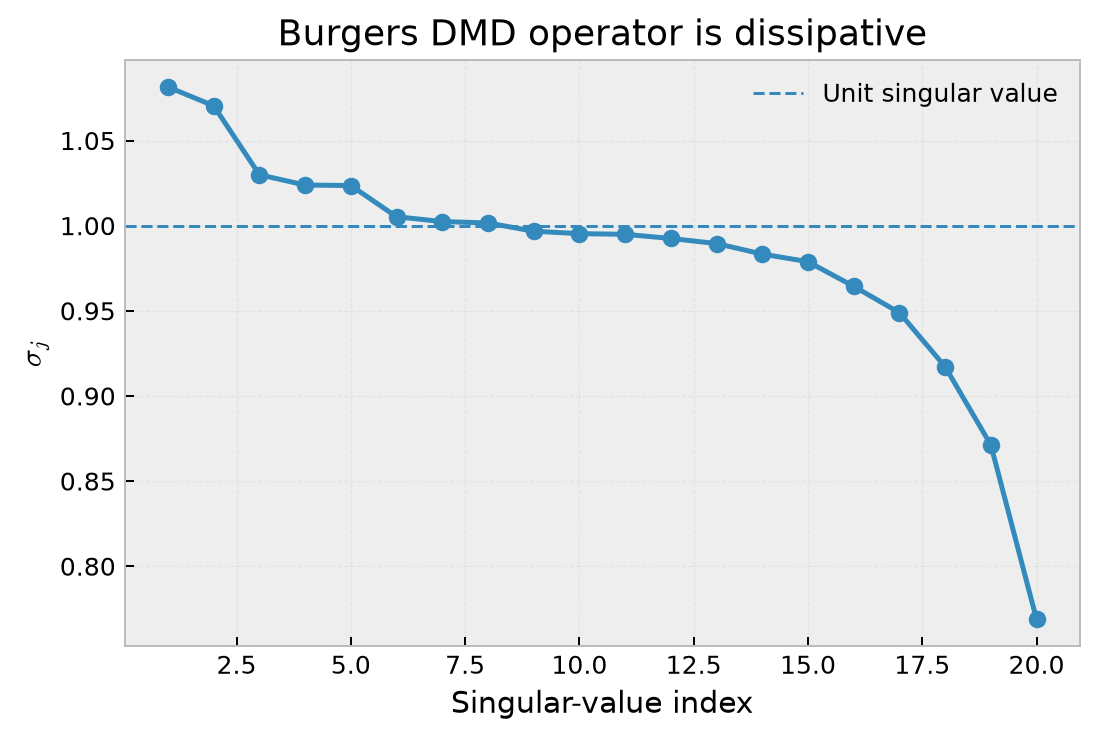

In [114]:
# ============================================================
# 12. SINGULAR VALUES
# ============================================================

sv = np.linalg.svd(
    Mr,
    compute_uv=False
)

fig, ax = plt.subplots(
    figsize=(6.2, 4.2),
    dpi=180
)

idx = np.arange(
    1,
    r + 1
)

ax.plot(
    idx,
    np.sort(sv)[::-1],
    'o-'
)

ax.axhline(
    1.0,
    linestyle='--',
    linewidth=1.2,
    label='Unit singular value'
)

ax.set_xlabel(
    'Singular-value index'
)

ax.set_ylabel(
    r'$\sigma_j$'
)

ax.set_title(
    'Burgers DMD operator is dissipative'
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [115]:
# ============================================================
# BURGERS: CHECK THE SPECTRAL OBSTRUCTION
# ============================================================

mod_lam = np.abs(lam)

print("Eigenvalue moduli:")
print(np.sort(mod_lam)[::-1])

print("\nMaximum modulus:")
print(mod_lam.max())

print("\nMinimum modulus:")
print(mod_lam.min())

print("\nMaximum deviation from unit modulus:")
print(np.max(np.abs(mod_lam - 1.0)))

print("\nNumber with |lambda-1| tolerance 1e-6:")
print(np.sum(np.abs(mod_lam - 1.0) < 1e-6))

print("\nNumber strictly inside unit circle (tol=1e-6):")
print(np.sum(mod_lam < 1.0 - 1e-6))

Eigenvalue moduli:
[0.99436782 0.99170229 0.99170229 0.99145242 0.99145242 0.98994119
 0.98994119 0.98660113 0.98660113 0.98077728 0.98077728 0.97343568
 0.97343568 0.9731026  0.96841743 0.96841743 0.96652598 0.96652598
 0.96341794 0.96341794]

Maximum modulus:
0.9943678201648131

Minimum modulus:
0.9634179445970236

Maximum deviation from unit modulus:
0.03658205540297643

Number with |lambda-1| tolerance 1e-6:
0

Number strictly inside unit circle (tol=1e-6):
20


In [116]:
# ============================================================
# SINGULAR VALUES OF BURGERS DMD OPERATOR
# ============================================================

sv_B = np.linalg.svd(Mr, compute_uv=False)

print("Singular values:")
print(np.sort(sv_B)[::-1])

print("\n||Mr^T Mr - I||_F =",
      np.linalg.norm(Mr.T @ Mr - np.eye(Mr.shape[0]), 'fro'))

Singular values:
[1.08146236 1.07042019 1.0299184  1.02385264 1.02359021 1.00524864
 1.00240811 1.00158568 0.9967492  0.99532307 0.99492469 0.99249174
 0.98949853 0.98333191 0.9788427  0.96438768 0.94891175 0.91714192
 0.87119101 0.76875894]

||Mr^T Mr - I||_F = 0.5723733473158129


Reduced dimension = 20

Initial objective:
0.016380562435875407

Optimization success = False
Message = STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

GEOMETRIC INVARIANCE DEFECT
Standard geometry relative residual = 0.12798657131072544
Adapted geometry relative residual  = 0.009589511584066452
Improvement factor = 13.346516158693921

Eigenvalues of G*:
[1.94384132e-10 8.60530894e-04 2.18705786e-02 2.84754905e-02
 4.25181326e-02 8.88917678e-02 1.21525157e-01 2.07394660e-01
 2.39383519e-01 3.51379463e-01 4.21816403e-01 5.38454088e-01
 7.18531100e-01 8.67225293e-01 1.02700300e+00 1.43164125e+00
 1.46582718e+00 2.78945772e+00 3.25266732e+00 6.38507735e+00]

Condition number G* = 32847741579.495914

SINGULAR VALUES

Original:
[1.08146236 1.07042019 1.0299184  1.02385264 1.02359021 1.00524864
 1.00240811 1.00158568 0.9967492  0.99532307 0.99492469 0.99249174
 0.98949853 0.98333191 0.9788427  0.96438768 0.94891175 0.91714192
 0.87119101 0.76875894]

After approximate metric adaptation:
[9

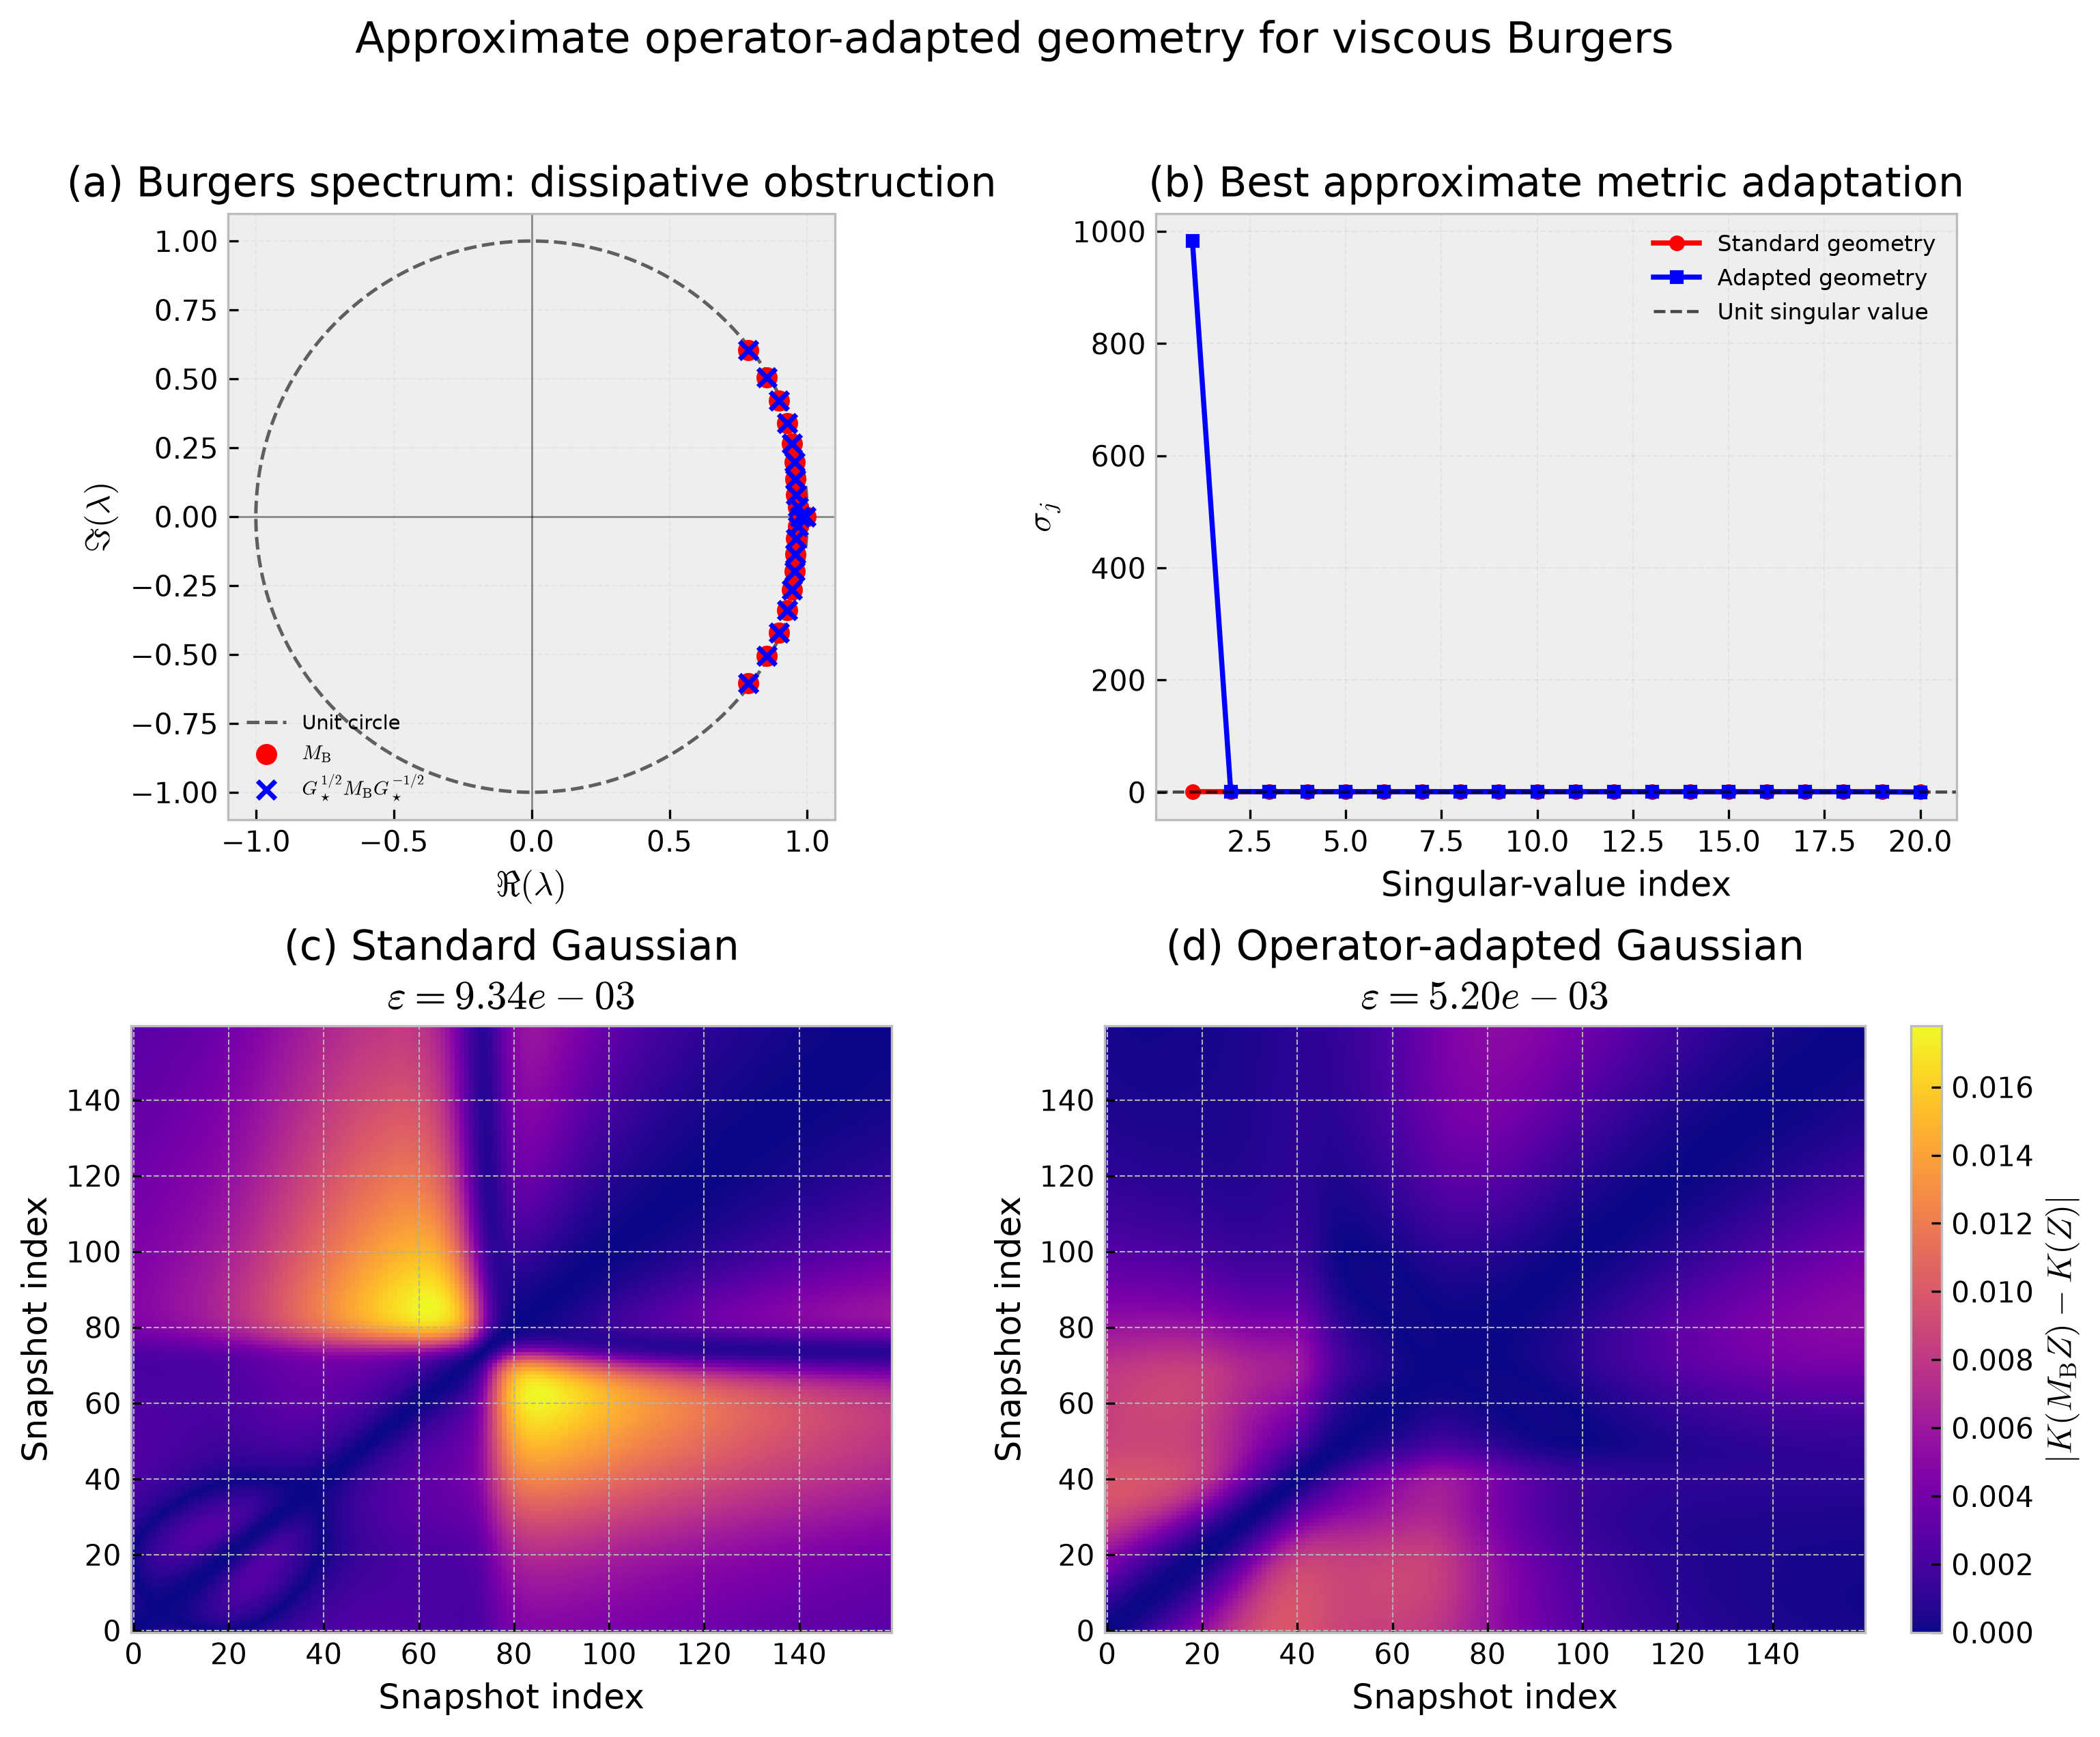

In [117]:
# ============================================================
# BURGERS: OPERATOR-ADAPTED GEOMETRY
# Approximate adaptation because exact unitarization is
# obstructed by eigenvalues inside the unit circle.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize


# ============================================================
# 1. BASIC SETUP
# ============================================================

M = Mr.copy()
r = M.shape[0]

print("Reduced dimension =", r)


# ============================================================
# 2. PARAMETERIZE G = L L^T
#
# This guarantees G > 0.
#
# Diagonal entries of L are exp(a_i), ensuring positivity.
# Lower triangular entries are unconstrained.
# ============================================================

def unpack_G(p, r):

    L = np.zeros((r, r))

    count = 0

    # Positive diagonal
    for i in range(r):
        L[i, i] = np.exp(p[count])
        count += 1

    # Lower triangular part
    for i in range(1, r):
        for j in range(i):
            L[i, j] = p[count]
            count += 1

    G = L @ L.T

    # Normalize scale:
    # trace(G) = r
    G *= r / np.trace(G)

    return G


# Number of parameters
nparams = r + r*(r-1)//2

# Start from G = I
p0 = np.zeros(nparams)


# ============================================================
# 3. OBJECTIVE
#
# Minimize relative invariance defect
#
#       ||M^T G M - G||_F^2
#       ---------------------
#              ||G||_F^2
# ============================================================

def objective(p):

    G = unpack_G(p, r)

    R = M.T @ G @ M - G

    return (
        np.linalg.norm(R, ord='fro')**2
        /
        np.linalg.norm(G, ord='fro')**2
    )


print("\nInitial objective:")
print(objective(p0))


# ============================================================
# 4. OPTIMIZE
# ============================================================

result = minimize(
    objective,
    p0,
    method='L-BFGS-B',
    options={
        'maxiter': 3000,
        'ftol': 1e-14,
        'gtol': 1e-10,
        'maxls': 50
    }
)

print("\nOptimization success =", result.success)
print("Message =", result.message)

Gstar = unpack_G(
    result.x,
    r
)


# ============================================================
# 5. CHECK ADAPTED METRIC
# ============================================================

Rstar = (
    M.T @ Gstar @ M
    -
    Gstar
)

relative_residual = (
    np.linalg.norm(Rstar, 'fro')
    /
    np.linalg.norm(Gstar, 'fro')
)

standard_residual = (
    np.linalg.norm(
        M.T @ M - np.eye(r),
        'fro'
    )
    /
    np.linalg.norm(
        np.eye(r),
        'fro'
    )
)

print("\n==========================================")
print("GEOMETRIC INVARIANCE DEFECT")
print("==========================================")

print(
    "Standard geometry relative residual =",
    standard_residual
)

print(
    "Adapted geometry relative residual  =",
    relative_residual
)

print(
    "Improvement factor =",
    standard_residual / relative_residual
)

print("\nEigenvalues of G*:")

eigG = np.linalg.eigvalsh(Gstar)

print(eigG)

print(
    "\nCondition number G* =",
    np.linalg.cond(Gstar)
)


# ============================================================
# 6. CONSTRUCT ADAPTED REPRESENTATION
#
#       M_G = G^{1/2} M G^{-1/2}
# ============================================================

evals_G, evecs_G = np.linalg.eigh(Gstar)

Ghalf = (
    evecs_G
    @ np.diag(np.sqrt(evals_G))
    @ evecs_G.T
)

Gmhalf = (
    evecs_G
    @ np.diag(1.0 / np.sqrt(evals_G))
    @ evecs_G.T
)

M_adapt = (
    Ghalf
    @ M
    @ Gmhalf
)


# ============================================================
# 7. SPECTRUM
# ============================================================

lam_original = np.linalg.eigvals(M)

lam_adapt = np.linalg.eigvals(M_adapt)


# ============================================================
# 8. SINGULAR VALUES
# ============================================================

sv_original = np.linalg.svd(
    M,
    compute_uv=False
)

sv_adapt = np.linalg.svd(
    M_adapt,
    compute_uv=False
)

print("\n==========================================")
print("SINGULAR VALUES")
print("==========================================")

print("\nOriginal:")
print(np.sort(sv_original)[::-1])

print("\nAfter approximate metric adaptation:")
print(np.sort(sv_adapt)[::-1])


# ============================================================
# 9. RKHS SIMILARITY TEST
#
# IMPORTANT:
# Use the actual reduced Burgers coordinates.
#
# Xr was constructed earlier from the Burgers snapshots:
#
#       Xr = Ur.T @ X
#
# Each column is one reduced Burgers state.
# ============================================================

Z = Xr.T.copy()

# Transform each reduced state using M
MZ = Z @ M.T


# ============================================================
# 10. GAUSSIAN GRAM MATRIX
# ============================================================

def gaussian_gram(X, metric, sigma):

    diff = (
        X[:, None, :]
        -
        X[None, :, :]
    )

    D2 = np.einsum(
        '...i,ij,...j->...',
        diff,
        metric,
        diff
    )

    D2 = np.maximum(
        D2,
        0.0
    )

    return np.exp(
        -D2 / (2 * sigma**2)
    )


# ============================================================
# 11. CHOOSE BANDWIDTH FROM BURGERS DATA
#
# Median pairwise Euclidean distance.
# ============================================================

diff = (
    Z[:, None, :]
    -
    Z[None, :, :]
)

D2 = np.sum(
    diff**2,
    axis=-1
)

upper = D2[
    np.triu_indices_from(
        D2,
        k=1
    )
]

sigma_kernel = np.sqrt(
    np.median(upper)
)

print(
    "\nGaussian bandwidth sigma =",
    sigma_kernel
)


# ============================================================
# 12. STANDARD GAUSSIAN
# ============================================================

K_standard_before = gaussian_gram(
    Z,
    np.eye(r),
    sigma_kernel
)

K_standard_after = gaussian_gram(
    MZ,
    np.eye(r),
    sigma_kernel
)


# ============================================================
# 13. ADAPTED GAUSSIAN
# ============================================================

K_adapt_before = gaussian_gram(
    Z,
    Gstar,
    sigma_kernel
)

K_adapt_after = gaussian_gram(
    MZ,
    Gstar,
    sigma_kernel
)


# ============================================================
# 14. GRAM-MATRIX ERRORS
# ============================================================

err_standard = (
    np.linalg.norm(
        K_standard_after
        -
        K_standard_before,
        'fro'
    )
    /
    np.linalg.norm(
        K_standard_before,
        'fro'
    )
)

err_adapt = (
    np.linalg.norm(
        K_adapt_after
        -
        K_adapt_before,
        'fro'
    )
    /
    np.linalg.norm(
        K_adapt_before,
        'fro'
    )
)

print("\n==========================================")
print("RKHS PAIRWISE SIMILARITY")
print("==========================================")

print(
    "Standard Gaussian error =",
    err_standard
)

print(
    "Adapted Gaussian error  =",
    err_adapt
)


# ============================================================
# 15. DIFFERENCE MATRICES
# ============================================================

D_standard = np.abs(
    K_standard_after
    -
    K_standard_before
)

D_adapt = np.abs(
    K_adapt_after
    -
    K_adapt_before
)

vmax = max(
    D_standard.max(),
    D_adapt.max()
)


# ============================================================
# 16. FINAL BURGERS FIGURE — 2 x 2
# ============================================================

fig = plt.figure(
    figsize=(11.5, 9.0),
    dpi=300
)

gs = fig.add_gridspec(
    2,
    2,
    wspace=0.28,
    hspace=0.34
)


# ------------------------------------------------------------
# (a) BURGERS DMD SPECTRUM
# ------------------------------------------------------------

ax1 = fig.add_subplot(
    gs[0, 0]
)

theta = np.linspace(
    0,
    2*np.pi,
    600
)

ax1.plot(
    np.cos(theta),
    np.sin(theta),
    '--',
    color='black',
    alpha=0.60,
    linewidth=1.2,
    label='Unit circle'
)

ax1.scatter(
    lam_original.real,
    lam_original.imag,
    s=48,
    color='red',
    marker='o',
    label=r'$M_{\mathrm{B}}$',
    zorder=3
)

# Adapted eigenvalues overlap because similarity
ax1.scatter(
    lam_adapt.real,
    lam_adapt.imag,
    s=40,
    color='blue',
    marker='x',
    linewidths=1.7,
    label=r'$G_\star^{1/2}M_{\mathrm{B}}G_\star^{-1/2}$',
    zorder=4
)

ax1.axhline(
    0,
    color='black',
    linewidth=0.7,
    alpha=0.4
)

ax1.axvline(
    0,
    color='black',
    linewidth=0.7,
    alpha=0.4
)

ax1.set_aspect(
    'equal'
)

ax1.set_xlim(
    -1.1,
    1.1
)

ax1.set_ylim(
    -1.1,
    1.1
)

ax1.set_xlabel(
    r'$\Re(\lambda)$'
)

ax1.set_ylabel(
    r'$\Im(\lambda)$'
)

ax1.set_title(
    '(a) Burgers spectrum: dissipative obstruction'
)

ax1.legend(
    frameon=False,
    fontsize=7,
    loc='lower left'
)

ax1.grid(
    alpha=0.15
)


# ------------------------------------------------------------
# (b) SINGULAR VALUES
# ------------------------------------------------------------

ax2 = fig.add_subplot(
    gs[0, 1]
)

idx = np.arange(
    1,
    r + 1
)

ax2.plot(
    idx,
    np.sort(sv_original)[::-1],
    'o-',
    color='red',
    linewidth=1.8,
    markersize=4.5,
    label='Standard geometry'
)

ax2.plot(
    idx,
    np.sort(sv_adapt)[::-1],
    's-',
    color='blue',
    linewidth=1.8,
    markersize=4,
    label='Adapted geometry'
)

ax2.axhline(
    1,
    linestyle='--',
    color='black',
    alpha=0.7,
    linewidth=1.1,
    label='Unit singular value'
)

ax2.set_xlabel(
    'Singular-value index'
)

ax2.set_ylabel(
    r'$\sigma_j$'
)

ax2.set_title(
    '(b) Best approximate metric adaptation'
)

ax2.legend(
    frameon=False,
    fontsize=8
)

ax2.grid(
    alpha=0.18
)


# ------------------------------------------------------------
# (c) STANDARD GAUSSIAN
# ------------------------------------------------------------

ax3 = fig.add_subplot(
    gs[1, 0]
)

im3 = ax3.imshow(
    D_standard,
    origin='lower',
    aspect='auto',
    vmin=0,
    vmax=vmax,
    cmap='plasma',
    interpolation='nearest'
)

ax3.set_title(
    '(c) Standard Gaussian\n'
    rf'$\varepsilon={err_standard:.2e}$'
)

ax3.set_xlabel(
    'Snapshot index'
)

ax3.set_ylabel(
    'Snapshot index'
)


# ------------------------------------------------------------
# (d) ADAPTED GAUSSIAN
# ------------------------------------------------------------

ax4 = fig.add_subplot(
    gs[1, 1]
)

im4 = ax4.imshow(
    D_adapt,
    origin='lower',
    aspect='auto',
    vmin=0,
    vmax=vmax,
    cmap='plasma',
    interpolation='nearest'
)

ax4.set_title(
    '(d) Operator-adapted Gaussian\n'
    rf'$\varepsilon={err_adapt:.2e}$'
)

ax4.set_xlabel(
    'Snapshot index'
)

ax4.set_ylabel(
    'Snapshot index'
)


# ------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im4,
    ax=[ax3, ax4],
    fraction=0.025,
    pad=0.025
)

cbar.set_label(
    r'$|K(M_{\mathrm{B}}Z)-K(Z)|$'
)


fig.suptitle(
    r'Approximate operator-adapted geometry for viscous Burgers',
    fontsize=15,
    y=0.985
)

plt.show()

In [118]:
eigG = np.linalg.eigvalsh(Gstar)

print("Eigenvalues of G*:")
print(eigG)

print("\nlambda_min(G*) =", eigG.min())
print("lambda_max(G*) =", eigG.max())

print("\ncond(G*) =", np.linalg.cond(Gstar))

print("\nRelative invariance residual:")
print(
    np.linalg.norm(Mr.T @ Gstar @ Mr - Gstar, 'fro')
    /
    np.linalg.norm(Gstar, 'fro')
)

Eigenvalues of G*:
[1.94384132e-10 8.60530894e-04 2.18705786e-02 2.84754905e-02
 4.25181326e-02 8.88917678e-02 1.21525157e-01 2.07394660e-01
 2.39383519e-01 3.51379463e-01 4.21816403e-01 5.38454088e-01
 7.18531100e-01 8.67225293e-01 1.02700300e+00 1.43164125e+00
 1.46582718e+00 2.78945772e+00 3.25266732e+00 6.38507735e+00]

lambda_min(G*) = 1.943841319412883e-10
lambda_max(G*) = 6.38507734760544

cond(G*) = 32847741579.495914

Relative invariance residual:
0.009589511584066452
